# Hydraulic Predictive Maintenance — Stage 1: Exploratory Data Analysis

**Client:** Bosch Rexroth AG · **Domain:** Industrial hydraulics (Hydraulic Power Units, HPUs)
**Stage:** 1 of 7 — Data understanding, quality assessment and pattern discovery
**Notebook:** `01_EDA_Hydraulic_Predictive_Maintenance.ipynb`

---

## Business context

Hydraulic failures at Bosch Rexroth sites are mostly handled **reactively**: equipment is repaired after it breaks, which causes unplanned downtime, emergency repair costs and delivery delays. The goal of the wider project is a predictive maintenance system that:

1. **Classifies the failure mode** that is developing (pump wear, valve leakage, contamination, cylinder drift), and
2. **Estimates Remaining Useful Life (RUL)** so maintenance can be scheduled before a breakdown.

## What this notebook sets out to answer

| # | Question | Why it matters downstream |
|---|----------|---------------------------|
| Q1 | Does the delivered data match the agreed data contract (schema, types, keys)? | Ingestion and validation pipeline design |
| Q2 | How clean is the data: missing values, dropouts, glitches, frozen sensors? | Cleaning rules and data validation tests in CI |
| Q3 | How are the targets (`failure_mode`, `rul_hours`) built, and are they usable as they are? | Labeling strategy, target leakage, class imbalance |
| Q4 | What normal operating patterns (shifts, weekends, load) exist? | Regime normalisation in feature engineering |
| Q5 | Does each failure mode leave a distinct sensor "fingerprint", and how early does it appear? | Feature selection and achievable warning lead time |
| Q6 | What do the failure and maintenance records say about cost and downtime? | Business case and model success criteria |

## Contents
1. Environment setup
2. Data loading
3. Schema validation against the data contract
4. Data quality assessment
5. Univariate analysis
6. Target analysis (failure mode and RUL)
7. Temporal patterns and operating regimes
8. Failure signatures and early-warning lead time
9. Multivariate relationships and statistical testing
10. Failure events, maintenance history and business impact
11. Summary of findings and recommendations for Stage 2

## 1. Environment setup

The notebook runs on a standard Google Colab runtime; every library it uses is pre-installed there. The cell below prints library versions so results can be reproduced later (this will also go into the project `requirements.txt` in Stage 2).

In [1]:
import os, sys, warnings, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for lib in (np, pd, mpl, sns):
    print(f"{lib.__name__:<12}{lib.__version__}")
import scipy, statsmodels, sklearn
for lib in (scipy, statsmodels, sklearn):
    print(f"{lib.__name__:<12}{lib.__version__}")
print(f"{'python':<12}{platform.python_version()}")

numpy       2.4.4
pandas      2.2.2
matplotlib  3.10.9
seaborn     0.13.2
scipy       1.17.1
statsmodels 0.15.0
sklearn     1.8.0
python      3.11.15


### 1.1 Plot style and project constants

One consistent colour per failure mode is used in every chart, so a colour always means the same thing across the notebook. `healthy` is a neutral grey so the failure modes stand out.

In [2]:
SENSORS = ["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g", "vibration_y_g", "pump_rpm"]
SENSOR_LABELS = {
    "pressure_bar": "Pressure (bar)", "temp_celsius": "Oil temperature (°C)", "flow_lpm": "Flow (L/min)",
    "vibration_x_g": "Vibration X (g)", "vibration_y_g": "Vibration Y (g)", "pump_rpm": "Pump speed (rpm)",
}
MODES = ["pump_wear", "valve_leakage", "contamination", "cylinder_drift"]
MODE_COLORS = {
    "healthy": "#9a9892", "pump_wear": "#2a78d6", "valve_leakage": "#eb6834",
    "contamination": "#1baf7a", "cylinder_drift": "#4a3aa7", "post_failure": "#e34948",
}
SHIFT_ORDER = ["Day", "Night", "Weekend"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "axes.titleweight": "semibold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.edgecolor": "#b5b3ab", "lines.linewidth": 1.8, "legend.frameon": False,
})

# Figures are also written to disk so they can be reused in reports / the dashboard.
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path("reports")
def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

### 1.2 Data access

The three source files are expected in one folder:

| File | Contents | Rows |
|------|----------|------|
| `sensor_telemetry.csv` | 1-minute sensor readings for 10 HPUs (≈74 MB) | 864,000 |
| `failure_labels.csv` | One row per failure event | 9 |
| `maintenance_log.csv` | Historical maintenance actions | 51 |

**Recommended (Google Drive):** put the files in `MyDrive/bosch_rexroth_pdm/data/raw/` (the project folder layout used from Stage 2 onwards) and keep `USE_DRIVE = True`. Data then survives runtime restarts and uploading 74 MB once is enough.
**Alternative:** set `USE_DRIVE = False` and upload the files when prompted (they are lost when the runtime resets).
Outside Colab, the notebook reads from `data/raw` (or `../data/raw` when run from `notebooks/`) or from the `PDM_DATA_DIR` environment variable.

In [3]:
IN_COLAB = "google.colab" in sys.modules
USE_DRIVE = True
DRIVE_DATA_DIR = "/content/drive/MyDrive/bosch_rexroth_pdm/data/raw"

FILES = {
    "telemetry": "sensor_telemetry.csv",
    "failures": "failure_labels.csv",
    "maintenance": "maintenance_log.csv",
}

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = Path(DRIVE_DATA_DIR)
    else:
        DATA_DIR = Path("/content/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    missing = [f for f in FILES.values() if not (DATA_DIR / f).exists()]
    if missing:
        print("Missing files, please upload:", missing)
        from google.colab import files
        for name, content in files.upload().items():
            (DATA_DIR / name).write_bytes(content)
else:
    candidates = [os.environ.get("PDM_DATA_DIR", ""), "data/raw", "../data/raw", "data"]
    DATA_DIR = next(Path(p) for p in candidates if p and (Path(p) / FILES["telemetry"]).exists())

for key, f in FILES.items():
    p = DATA_DIR / f
    assert p.exists(), f"{p} not found — check DATA_DIR"
    print(f"{key:<12} {p}  ({p.stat().st_size/1e6:,.1f} MB)")

telemetry    ../data/raw/sensor_telemetry.csv  (73.7 MB)
failures     ../data/raw/failure_labels.csv  (0.0 MB)
maintenance  ../data/raw/maintenance_log.csv  (0.0 MB)


## 2. Data loading

Types are declared up front rather than inferred. This avoids the mixed-type warning pandas raises on the sparse `failure_mode` column, halves memory use (`category` for low-cardinality strings, `float32` for sensors), and mirrors the typed schema the production ingestion step will enforce.

In [4]:
TELEMETRY_DTYPES = {
    "machine_id": "category", "pressure_bar": "float32", "temp_celsius": "float32", "flow_lpm": "float32",
    "vibration_x_g": "float32", "vibration_y_g": "float32", "pump_rpm": "float32", "is_anomaly": "int8",
    "failure_mode": "category", "rul_hours": "float32", "is_sensor_dropout": "int8",
    "shift": "category", "day_of_week": "int8",
}
tel = pd.read_csv(DATA_DIR / FILES["telemetry"], dtype=TELEMETRY_DTYPES, parse_dates=["timestamp"])
fail = pd.read_csv(DATA_DIR / FILES["failures"], parse_dates=["failure_timestamp", "degradation_start_timestamp"])
mnt = pd.read_csv(DATA_DIR / FILES["maintenance"], parse_dates=["action_timestamp"])
# Gotcha: pandas parses the literal string "None" in component_replaced as missing. Here it means
# "no component replaced", which is a valid category, so restore it explicitly.
mnt["component_replaced"] = mnt["component_replaced"].fillna("None")

tel = tel.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

for name, d in [("telemetry", tel), ("failure_labels", fail), ("maintenance_log", mnt)]:
    print(f"{name:<16} shape={d.shape}  memory={d.memory_usage(deep=True).sum()/1e6:,.1f} MB")

telemetry        shape=(864000, 14)  memory=36.3 MB
failure_labels   shape=(9, 7)  memory=0.0 MB
maintenance_log  shape=(51, 7)  memory=0.0 MB


In [5]:
display(tel.head())
display(fail)
display(mnt.head())

,timestamp,machine_id,pressure_bar,temp_celsius,flow_lpm,vibration_x_g,vibration_y_g,pump_rpm,is_anomaly,failure_mode,rul_hours,is_sensor_dropout,shift,day_of_week
0,2024-01-01 00:00:00,HPU_01,116.990,50.840,88.970,0.293,0.293,"1,473.000",0,NaN,500.000,0,Night,0
1,2024-01-01 00:01:00,HPU_01,116.370,50.170,87.210,0.067,0.067,"1,474.000",0,NaN,500.000,0,Night,0
2,2024-01-01 00:02:00,HPU_01,116.400,50.290,86.480,0.137,0.137,"1,467.000",0,NaN,500.000,0,Night,0
3,2024-01-01 00:03:00,HPU_01,116.300,50.830,88.900,0.496,0.496,"1,466.000",0,NaN,500.000,0,Night,0
4,2024-01-01 00:04:00,HPU_01,117.700,50.260,87.100,0.086,0.086,"1,469.000",0,NaN,500.000,0,Night,0


,failure_event_id,machine_id,failure_timestamp,failure_mode,degradation_start_timestamp,repair_cost_usd,downtime_hours
0,F_001,HPU_01,2024-02-15,pump_wear,2024-02-01,25094,13.200
1,F_002,HPU_02,2024-02-22,valve_leakage,2024-02-12,8711,9.800
2,F_003,HPU_03,2024-02-08,contamination,2024-02-03,24507,6.300
3,F_004,HPU_04,2024-02-28,pump_wear,2024-02-16,29482,22.400
4,F_005,HPU_05,2024-01-31,valve_leakage,2024-01-21,14065,8.200
5,F_006,HPU_06,2024-02-18,cylinder_drift,2024-02-10,23021,13.100
6,F_007,HPU_07,2024-02-25,valve_leakage,2024-02-15,11598,8.700
7,F_008,HPU_08,2024-02-12,pump_wear,2024-01-29,30336,14.500
8,F_009,HPU_09,2024-01-26,contamination,2024-01-21,16482,10.500


,maintenance_id,machine_id,action_timestamp,action_type,component_replaced,technician_id,cost_usd
0,M_026,HPU_05,2023-10-03 17:09:00,Reactive,Valve,T_001,7840
1,M_009,HPU_02,2023-10-04 20:06:00,Preventive,Filter,T_002,1896
2,M_036,HPU_08,2023-10-06 07:26:00,Preventive,Seal,T_004,738
3,M_023,HPU_05,2023-10-07 07:47:00,Preventive,Oil,T_001,1476
4,M_015,HPU_03,2023-10-10 06:41:00,Preventive,Seal,T_008,707


## 3. Schema validation against the data contract

The project brief defines three core tables (`Sensor_Telemetry`, `Failure_Events`, `Maintenance_Actions`). Before any analysis we check the delivered files against that contract: which columns are **missing**, which are **extra**, and which look **renamed**. In production this check becomes an automated gate in the ingestion pipeline (for example with `pandera` or Great Expectations) that quarantines non-conforming batches.

In [6]:
CONTRACT = {
    "telemetry": ["machine_id", "timestamp", "pressure_bar", "temp_celsius", "flow_lpm",
                  "vibration_x_g", "vibration_y_g", "pump_rpm"],
    "failures": ["event_id", "machine_id", "failure_timestamp", "failure_mode", "downtime_hours"],
    "maintenance": ["action_id", "machine_id", "action_timestamp", "action_type", "component_replaced"],
}
KNOWN_RENAMES = {"event_id": "failure_event_id", "action_id": "maintenance_id"}

rows = []
for key, d in [("telemetry", tel), ("failures", fail), ("maintenance", mnt)]:
    expected, actual = set(CONTRACT[key]), set(d.columns)
    for c in sorted(expected - actual):
        status = f"renamed → {KNOWN_RENAMES[c]}" if KNOWN_RENAMES.get(c) in actual else "MISSING"
        rows.append((key, c, status))
    renamed_targets = {KNOWN_RENAMES.get(c) for c in expected}
    for c in sorted(actual - expected - renamed_targets):
        rows.append((key, c, "extra (not in contract)"))
schema_report = pd.DataFrame(rows, columns=["table", "column", "status"])
display(schema_report)

print("\nAllowed action_type per contract: Preventive / Reactive / Predictive")
print("Observed action_type:", mnt["action_type"].value_counts().to_dict())
print("failure_timestamp has time component:", (fail["failure_timestamp"].dt.normalize() != fail["failure_timestamp"]).any())

,table,column,status
0,telemetry,day_of_week,extra (not in contract)
1,telemetry,failure_mode,extra (not in contract)
2,telemetry,is_anomaly,extra (not in contract)
3,telemetry,is_sensor_dropout,extra (not in contract)
4,telemetry,rul_hours,extra (not in contract)
5,telemetry,shift,extra (not in contract)
6,failures,event_id,renamed → failure_event_id
7,failures,degradation_start_timestamp,extra (not in contract)
8,failures,repair_cost_usd,extra (not in contract)
9,maintenance,action_id,renamed → maintenance_id



Allowed action_type per contract: Preventive / Reactive / Predictive
Observed action_type: {'Preventive': 33, 'Reactive': 14, 'Inspection': 4}
failure_timestamp has time component: False


**Findings: schema**

- **No contract columns are missing.** Two primary keys are renamed (`event_id` → `failure_event_id`, `action_id` → `maintenance_id`). This is harmless but has to be mapped in the ingestion layer.
- **The telemetry file contains label columns** (`is_anomaly`, `failure_mode`, `rul_hours`) and derived fields (`is_sensor_dropout`, `shift`, `day_of_week`). Real PLC/OPC-UA telemetry would not carry labels. They have been joined in upstream, so Section 6 checks how they were built before we trust them.
- The failure table adds `degradation_start_timestamp` and `repair_cost_usd`, and the maintenance table adds `technician_id` and `cost_usd`. All of these are useful.
- **Vocabulary drift:** `action_type` contains `Inspection` (not in the contract) and no `Predictive` actions, which confirms maintenance today is entirely reactive or schedule-based.
- `failure_timestamp` is **date-only** (midnight). RUL labels can therefore be up to about 24 h out of step with the true failure moment. This is worth raising with the data owner.

## 4. Data quality assessment

We check five dimensions: **completeness, timeliness/continuity, validity (physical ranges), consistency (frozen or duplicated signals)** and **accuracy (spikes)**. Every issue found is logged in a data quality register (§4.7) that feeds the Stage 2 validation rules.

### 4.1 Completeness: missing values and sensor dropouts

In [7]:
miss = tel.isna().sum().to_frame("n_missing")
miss["pct"] = 100 * miss["n_missing"] / len(tel)
display(miss[miss.n_missing > 0])

sensor_nan_rows = tel[SENSORS].isna().any(axis=1)
print("Rows with any sensor NaN :", sensor_nan_rows.sum())
print("Rows flagged is_sensor_dropout:", tel.is_sensor_dropout.sum())
print("NaN rows == dropout flag :", (sensor_nan_rows == tel.is_sensor_dropout.astype(bool)).all())
print("Partial-NaN rows (some sensors missing, not all):",
      (tel[SENSORS].isna().any(axis=1) & ~tel[SENSORS].isna().all(axis=1)).sum())

,n_missing,pct
pressure_bar,2590,0.300
temp_celsius,2590,0.300
flow_lpm,2590,0.300
vibration_x_g,2590,0.300
vibration_y_g,2590,0.300
pump_rpm,2590,0.300
failure_mode,737280,85.333


Rows with any sensor NaN : 2590
Rows flagged is_sensor_dropout: 2590
NaN rows == dropout flag : True
Partial-NaN rows (some sensors missing, not all): 0


433 dropout episodes | median 6 min | max 17 min


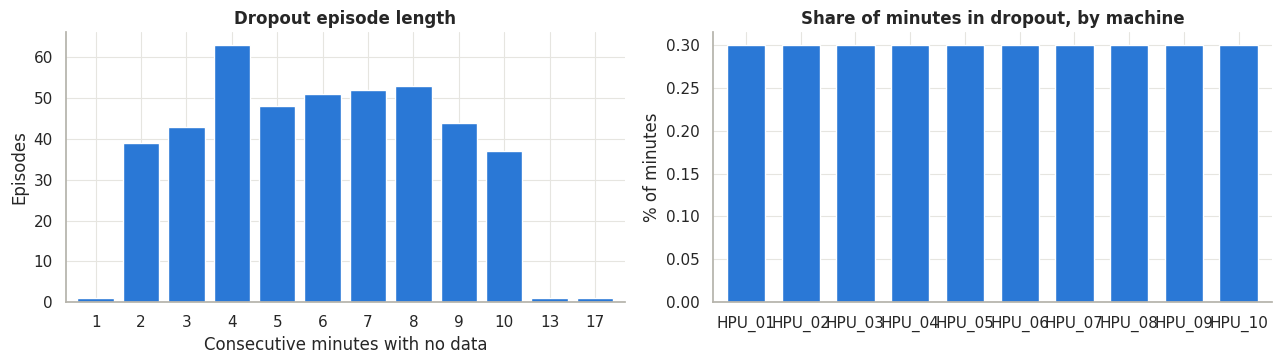

In [8]:
# Length of each contiguous dropout episode (in minutes)
flag = tel["is_sensor_dropout"].astype(bool)
episode_id = (flag != flag.shift()).cumsum() + tel["machine_id"].cat.codes.astype("int64") * 10**7
episodes = tel[flag].groupby(episode_id[flag]).agg(machine_id=("machine_id", "first"),
                                                   start=("timestamp", "first"), minutes=("timestamp", "size"))
print(f"{len(episodes)} dropout episodes | median {episodes.minutes.median():.0f} min | max {episodes.minutes.max()} min")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
episodes["minutes"].value_counts().sort_index().plot.bar(ax=axes[0], color=MODE_COLORS["pump_wear"], width=0.8)
axes[0].set(title="Dropout episode length", xlabel="Consecutive minutes with no data", ylabel="Episodes")
axes[0].tick_params(axis="x", rotation=0)
per_machine = tel.groupby("machine_id", observed=True)["is_sensor_dropout"].mean() * 100
per_machine.plot.bar(ax=axes[1], color=MODE_COLORS["pump_wear"], width=0.7)
axes[1].set(title="Share of minutes in dropout, by machine", xlabel="", ylabel="% of minutes")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); save(fig, "04_dropouts"); plt.show()

**Findings: completeness**

- About 0.3% of rows are missing. **Every missing value belongs to a flagged dropout** and every sensor drops out together, so these are whole-device communication losses, not single failed sensors.
- Dropouts are **short** (median about 6 min, never above about 17 min) and spread evenly across machines. **Recommendation:** fill gaps of 15 min or less by time-based interpolation per machine, keep an `was_imputed` indicator, and treat longer gaps as windows that are excluded from feature calculation.

### 4.2 Timeliness and continuity: sampling grid, duplicates and coverage

In [9]:
dups = tel.duplicated(["machine_id", "timestamp"]).sum()
steps = tel.groupby("machine_id", observed=True)["timestamp"].diff().dropna().value_counts()
coverage = tel.groupby("machine_id", observed=True)["timestamp"].agg(["min", "max", "count"])
coverage["expected"] = ((coverage["max"] - coverage["min"]) / pd.Timedelta("1min") + 1).astype(int)
print("Duplicate (machine_id, timestamp) keys:", dups)
print("Sampling intervals found:", steps.to_dict())
display(coverage)

Duplicate (machine_id, timestamp) keys: 0
Sampling intervals found: {Timedelta('0 days 00:01:00'): 863990}


,min,max,count,expected
machine_id,,,,
HPU_01,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_02,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_03,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_04,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_05,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_06,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_07,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_08,2024-01-01,2024-02-29 23:59:00,86400,86400
HPU_09,2024-01-01,2024-02-29 23:59:00,86400,86400


**Findings: continuity.** The data sits on a perfect 1-minute grid: no duplicate keys, no missing timestamps, and 60 days (1 Jan to 29 Feb 2024) of full coverage for all 10 machines. That makes window-based features simple and reliable. **Caveat:** timestamps have no timezone information. The contract says UTC, which has to be confirmed before joining with MES or maintenance systems that may use local time.

### 4.3 Validity: physical range checks

The ranges below are **engineering plausibility bounds**, not statistical cut-offs. They are initial assumptions and should be confirmed by a Rexroth hydraulics engineer against the actual HPU specifications:

| Sensor | Plausible range | Rationale |
|---|---|---|
| Pressure | 0 – 350 bar | Typical industrial HPU maximum working pressure |
| Oil temperature | 10 – 90 °C | Mineral oil cannot be below ambient during operation; above 90 °C degrades oil |
| Flow | 0 – 150 L/min | Above pump displacement capacity |
| Vibration | 0 – 16 g | Accelerometer range; values stay physical |
| Pump speed | 1,200 – 1,600 rpm | Rated band for a 4-pole motor drive |

In [10]:
RANGES = {"pressure_bar": (0, 350), "temp_celsius": (10, 90), "flow_lpm": (0, 150),
          "vibration_x_g": (0, 16), "vibration_y_g": (0, 16), "pump_rpm": (1200, 1600)}
health = tel["failure_mode"].astype(str).replace("nan", "healthy")

rows = []
for s, (lo, hi) in RANGES.items():
    low, high = tel[s] < lo, tel[s] > hi
    rows.append({"sensor": s, "range": f"[{lo}, {hi}]", "below": int(low.sum()), "above": int(high.sum()),
                 "min_seen": float(tel[s].min()), "max_seen": float(tel[s].max()),
                 "share_in_degradation_windows": round(float((health[low | high] != "healthy").mean()), 3) if (low | high).any() else np.nan})
range_report = pd.DataFrame(rows)
display(range_report)

,sensor,range,below,above,min_seen,max_seen,share_in_degradation_windows
0,pressure_bar,"[0, 350]",0,250,42.960,598.471,0.124
1,temp_celsius,"[10, 90]",170,0,-9.945,64.860,0.200
2,flow_lpm,"[0, 150]",0,0,31.250,108.130,NaN
3,vibration_x_g,"[0, 16]",0,0,0.050,14.739,NaN
4,vibration_y_g,"[0, 16]",0,0,0.050,14.965,NaN
5,pump_rpm,"[1200, 1600]",14358,0,"1,000.000","1,540.000",0.000


Pressure > 350 bar isolated single-minute events: 100%


Temperature < 10 °C isolated single-minute events: 100%


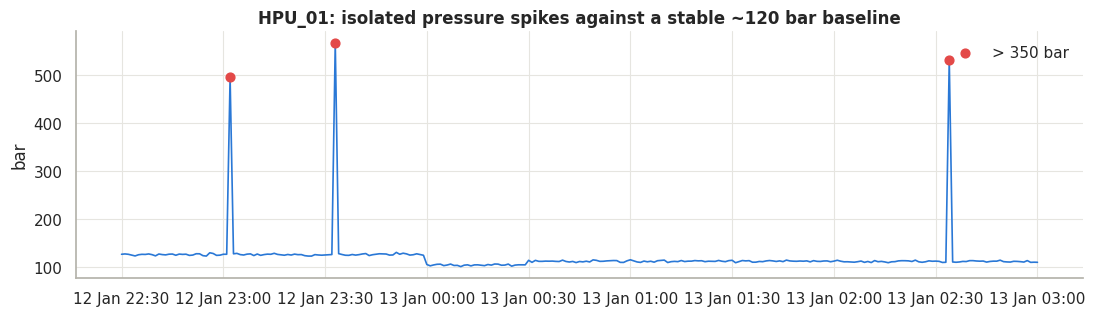

In [11]:
# Are out-of-range readings isolated one-minute glitches, or sustained excursions?
def isolated_share(mask):
    m = mask.astype(int)
    grp = tel["machine_id"]
    prev_ = m.groupby(grp, observed=True).shift(1, fill_value=0)
    next_ = m.groupby(grp, observed=True).shift(-1, fill_value=0)
    return ((m == 1) & (prev_ == 0) & (next_ == 0)).sum() / max(m.sum(), 1)

print(f"Pressure > 350 bar isolated single-minute events: {isolated_share(tel.pressure_bar > 350):.0%}")
print(f"Temperature < 10 °C isolated single-minute events: {isolated_share(tel.temp_celsius < 10):.0%}")

m = "HPU_01"; d = tel[(tel.machine_id == m) & (tel.timestamp.between("2024-01-12 22:30", "2024-01-13 03:00"))]
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(d.timestamp, d.pressure_bar, color=MODE_COLORS["pump_wear"], lw=1.2)
spk = d[d.pressure_bar > 350]
ax.scatter(spk.timestamp, spk.pressure_bar, color=MODE_COLORS["post_failure"], s=40, zorder=3, label="> 350 bar")
ax.set(title=f"{m}: isolated pressure spikes against a stable ~120 bar baseline", ylabel="bar")
ax.legend(loc="upper right"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %H:%M"))
save(fig, "04_pressure_spikes"); plt.show()

**Findings: validity**

- **Pressure spikes of 450–600 bar** (about 250 rows) and **negative oil temperatures down to −10 °C** (about 170 rows) are physically impossible, and almost all of them are **isolated single-minute readings**. The behaviour matches electrical noise or ADC glitches, not real process events, and the glitches occur in healthy and degraded periods alike.
- **Recommendation:** treat these as invalid measurements: set them to NaN and interpolate, and never clip them to the boundary. Clipping would create artificial extreme values that tree models would pick up as signal. Counting glitches per day can also be kept as a *sensor-health* feature.
- The rpm rule also flags about 14k readings of exactly 1,000 rpm. These are **not** glitches (see §4.4).

### 4.4 Consistency: frozen sensors and the 1,000 rpm readings

In [12]:
# Generic flat-line detector: longest run of identical consecutive readings per sensor
def max_flat_run(s):
    runs = (s != s.shift()).cumsum()
    return s.groupby(runs).transform("size").max()
flat = {s: int(tel.groupby("machine_id", observed=True)[s].apply(max_flat_run).max()) for s in SENSORS}
print("Longest run of identical consecutive values per sensor (minutes):", flat)

rpm1000 = tel["pump_rpm"] == 1000
print(f"\npump_rpm == 1000 exactly : {rpm1000.sum():,} rows ({rpm1000.mean():.2%})")
print("Dates                    :", tel.loc[rpm1000, "timestamp"].dt.date.value_counts().to_dict())
print("Machines affected        :", tel.loc[rpm1000, "machine_id"].nunique(), "of", tel.machine_id.nunique())

Longest run of identical consecutive values per sensor (minutes): {'pressure_bar': 3, 'temp_celsius': 3, 'flow_lpm': 3, 'vibration_x_g': 8, 'vibration_y_g': 8, 'pump_rpm': 1440}

pump_rpm == 1000 exactly : 14,358 rows (1.66%)
Dates                    : {datetime.date(2024, 1, 15): 14358}
Machines affected        : 10 of 10


,pressure_bar,flow_lpm,temp_celsius,vibration_x_g,pump_rpm
Mon 15 Jan (all 10 HPUs),49.950,34.795,44.210,0.084,"1,000.000"
Tue 16 Jan (all 10 HPUs),130.425,91.585,52.340,0.086,"1,492.000"


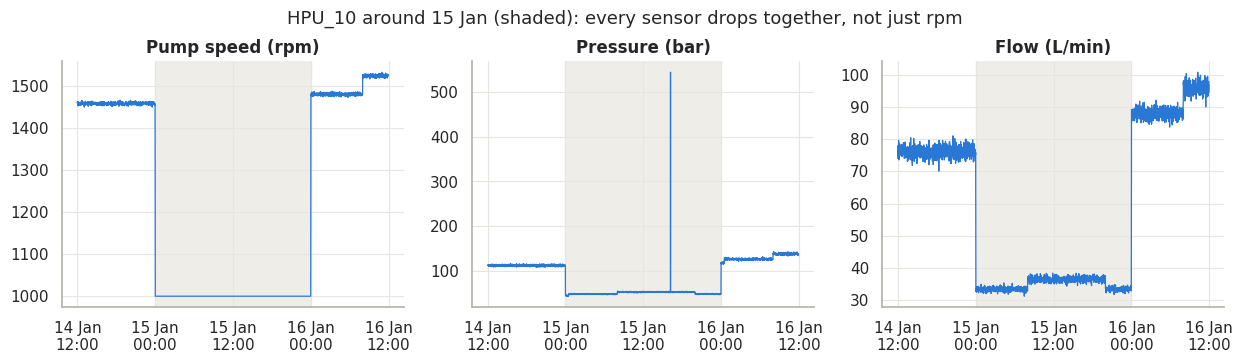

In [13]:
# Is it a stuck rpm transducer, or did the whole plant genuinely run differently that day?
day = tel.timestamp.dt.normalize()
cmp_days = (tel[day.isin(pd.to_datetime(["2024-01-15", "2024-01-16"]))]
            .groupby(day, observed=True)[["pressure_bar", "flow_lpm", "temp_celsius", "vibration_x_g", "pump_rpm"]].median())
cmp_days.index = ["Mon 15 Jan (all 10 HPUs)", "Tue 16 Jan (all 10 HPUs)"]
display(cmp_days)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2), sharex=True)
w = tel[(tel.machine_id == "HPU_10") & tel.timestamp.between("2024-01-14 12:00", "2024-01-16 12:00")]
for ax, s in zip(axes, ["pump_rpm", "pressure_bar", "flow_lpm"]):
    ax.plot(w.timestamp, w[s], color=MODE_COLORS["pump_wear"], lw=0.9)
    ax.axvspan(pd.Timestamp("2024-01-15"), pd.Timestamp("2024-01-16"), color="#eeede8", zorder=0)
    ax.set(title=SENSOR_LABELS[s])
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
fig.suptitle("HPU_10 around 15 Jan (shaded): every sensor drops together, not just rpm", y=1.04, fontsize=13)
save(fig, "04_standby_day"); plt.show()

**Findings: consistency**

- The only long flat-line is `pump_rpm`, which reads **exactly 1,000 rpm for 24 hours on Monday 15 January, on all 10 machines at once**.
- That is **not** a stuck transducer. On the same day pressure drops to about 50 bar, flow to about 35 L/min and oil temperature to about 44 °C, and all three are consistent with the pump running slowly. This is a **fleet-wide standby / reduced-production day**, a real operating regime that nobody documented.
- **Implications:**
  1. It must be tagged as its own `Standby` regime.
  2. It must be excluded when estimating "healthy" baselines, because it would distort them badly.
  3. A naive detector would flag the whole fleet as failing that day (we show this in §8.3).
  4. **Operations should confirm** what happened on that day (holiday, planned shutdown, energy-saving mode?).
- No other sensor shows flat-lines longer than a few minutes, so there is no evidence of frozen transducers.

### 4.5 Accuracy: statistical spike detection (Hampel filter)

Range checks only catch impossible values. A **Hampel filter** (rolling median ± 5 × scaled MAD over a 15-minute window, per machine) also flags readings that are plausible in absolute terms but inconsistent with the minutes around them. The comparison shows how much of the noise the simple rules above already catch.

In [14]:
def hampel_flags(s, window=15, k=5.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median() * 1.4826
    return (s - med).abs() > k * mad.replace(0, np.nan)

rows = []
for s in ["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g"]:
    f = tel.groupby("machine_id", observed=True, group_keys=False)[s].apply(hampel_flags)
    lo, hi = RANGES[s]
    rows.append({"sensor": s, "hampel_flags": int(f.sum()), "pct": round(100 * f.mean(), 3),
                 "also_out_of_range": int((f & ((tel[s] < lo) | (tel[s] > hi))).sum()),
                 "flags_in_degradation": round(float((health[f] != "healthy").mean()), 3)})
display(pd.DataFrame(rows))

,sensor,hampel_flags,pct,also_out_of_range,flags_in_degradation
0,pressure_bar,3546,0.410,250,0.394
1,temp_celsius,2197,0.254,170,0.139
2,flow_lpm,2171,0.251,0,0.144
3,vibration_x_g,26267,3.040,0,0.205


**Finding.** The Hampel filter flags far more points than the range rules, and **14–39% of its flags fall inside degradation windows**, even though those windows are only ~15% of the data. Many of the flagged points, such as the bursty high-g vibration during contamination, are the **genuine failure signal**. **An aggressive outlier filter would delete the very evidence we want the model to learn from.** Recommendation: remove only the physically impossible values (§4.3, §4.4), and let robust rolling statistics (median, quantiles) absorb the rest during feature engineering.

### 4.6 Redundancy: are the two vibration axes independent?

In [15]:
same = (tel.vibration_x_g == tel.vibration_y_g) | tel.vibration_x_g.isna()
print(f"vibration_x_g == vibration_y_g in {same.mean():.1%} of rows")
display(pd.DataFrame({"share_identical": same.groupby(health).mean().round(4),
                      "rows": health.value_counts()}).sort_values("share_identical"))

vibration_x_g == vibration_y_g in 98.1% of rows


,share_identical,rows
failure_mode,,
cylinder_drift,0.006,11520
contamination,0.640,14400
healthy,1.000,737280
valve_leakage,1.000,43200
pump_wear,1.000,57600


**Finding.** In about 98% of rows **the X and Y vibration readings are identical to 4 decimal places**, which never happens with two physically separate accelerometers. The two channels only differ during **cylinder drift** and **contamination**. Two possibilities:
1. One channel is duplicated upstream (for example an OPC-UA tag mapping error), or
2. The data is partly simulated.

Either way, `vibration_y_g` adds **almost no independent information** in normal operation, while **the X − Y difference is itself a strong diagnostic feature** (see §8.4). This has to be raised with the data owner before the data is used for real-world deployment.

### 4.7 Data quality issue register

In [16]:
dq_register = pd.DataFrame([
    ("DQ-01", "Completeness", "All-sensor dropouts (≤17 min episodes)", int(tel.is_sensor_dropout.sum()), "Time-interpolate ≤15 min per machine, add imputed flag", "Medium"),
    ("DQ-02", "Validity", "Pressure spikes > 350 bar (single-minute)", int((tel.pressure_bar > 350).sum()), "Set NaN → interpolate; count as sensor-health feature", "High"),
    ("DQ-03", "Validity", "Oil temperature < 10 °C (single-minute)", int((tel.temp_celsius < 10).sum()), "Set NaN → interpolate", "High"),
    ("DQ-04", "Context", "Undocumented fleet-wide standby day, 15 Jan (rpm = 1000)", int(rpm1000.sum()), "Tag as 'Standby' regime; exclude from baselines; confirm with operations", "High"),
    ("DQ-05", "Redundancy", "vibration_y_g duplicates vibration_x_g (~98%)", int(same.sum()), "Escalate to data owner; use X−Y delta as feature", "High"),
    ("DQ-06", "Label", "failure_timestamp is date-only", len(fail), "Request exact failure time from CMMS", "Medium"),
    ("DQ-07", "Label", "RUL = 0 after repair / RUL = 500 sentinel (see §6)", int(((tel.rul_hours == 0) & (tel.is_anomaly == 0)).sum()), "Rebuild RUL target in Stage 2", "Critical"),
    ("DQ-08", "Coverage", "Maintenance log does not overlap telemetry period (see §10)", len(mnt), "Request 2024 maintenance records", "High"),
    ("DQ-09", "Schema", "Renamed keys, extra label columns, 'Inspection' action type", 3, "Map in ingestion layer; update data contract", "Low"),
], columns=["id", "dimension", "issue", "rows_affected", "remediation", "severity"])
dq_register.to_csv(REPORT_DIR / "data_quality_register.csv", index=False)
dq_register

,id,dimension,issue,rows_affected,remediation,severity
0,DQ-01,Completeness,All-sensor dropouts (≤17 min episodes),2590,"Time-interpolate ≤15 min per machine, add impu...",Medium
1,DQ-02,Validity,Pressure spikes > 350 bar (single-minute),250,Set NaN → interpolate; count as sensor-health ...,High
2,DQ-03,Validity,Oil temperature < 10 °C (single-minute),170,Set NaN → interpolate,High
3,DQ-04,Context,"Undocumented fleet-wide standby day, 15 Jan (r...",14358,Tag as 'Standby' regime; exclude from baseline...,High
4,DQ-05,Redundancy,vibration_y_g duplicates vibration_x_g (~98%),847287,Escalate to data owner; use X−Y delta as feature,High
5,DQ-06,Label,failure_timestamp is date-only,9,Request exact failure time from CMMS,Medium
6,DQ-07,Label,RUL = 0 after repair / RUL = 500 sentinel (see...,211680,Rebuild RUL target in Stage 2,Critical
7,DQ-08,Coverage,Maintenance log does not overlap telemetry per...,51,Request 2024 maintenance records,High
8,DQ-09,Schema,"Renamed keys, extra label columns, 'Inspection...",3,Map in ingestion layer; update data contract,Low


### 4.8 Analysis-ready view

For the rest of this EDA we use a **lightly cleaned copy**. The raw data is left untouched. This is an EDA convenience only; Stage 2 will implement the same rules as a tested, versioned pipeline step.

- Impossible values (DQ-02/03) are set to NaN, and short gaps (DQ-01) are interpolated per machine.
- An explicit **operating regime** column is added: `Standby` (15 Jan), `Weekend`, `Day` or `Night`.

In [17]:
df = tel.copy()
df.loc[df.pressure_bar > 350, "pressure_bar"] = np.nan
df.loc[df.temp_celsius < 10, "temp_celsius"] = np.nan
df[SENSORS] = (df.groupby("machine_id", observed=True, group_keys=False)[SENSORS]
                 .apply(lambda g: g.interpolate(limit=15, limit_direction="both")))

STANDBY_DATES = pd.to_datetime(["2024-01-15"])
df["is_standby"] = df.timestamp.dt.normalize().isin(STANDBY_DATES)
df["regime"] = np.where(df.is_standby, "Standby", df["shift"].astype(str))
df["day_type"] = np.where(df.is_standby, "Standby", np.where(df.day_of_week >= 5, "Weekend", "Weekday"))
df["hour"] = df.timestamp.dt.hour

# Attach event metadata and a health-state label that separates post-failure data
df = df.merge(fail[["machine_id", "failure_timestamp", "degradation_start_timestamp"]], on="machine_id", how="left")
df["state"] = np.select(
    [df.failure_mode.notna(), df.failure_timestamp.notna() & (df.timestamp >= df.failure_timestamp)],
    [df.failure_mode.astype(str), "post_failure"], default="healthy")
df["hours_to_failure"] = (df.failure_timestamp - df.timestamp) / pd.Timedelta("1h")
df["state"].value_counts()

state
healthy           525600
post_failure      211680
pump_wear          57600
valve_leakage      43200
contamination      14400
cylinder_drift     11520
Name: count, dtype: int64

## 5. Univariate analysis

In [18]:
desc = df[SENSORS].describe(percentiles=[.01, .25, .5, .75, .99]).T
desc["skew"] = df[SENSORS].skew(); desc["kurtosis"] = df[SENSORS].kurt()
desc

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
pressure_bar,"864,000.000",123.640,15.317,42.960,51.862,112.990,125.920,136.610,141.740,167.700,-1.961,7.005
temp_celsius,"864,000.000",52.230,2.134,43.190,44.530,51.080,52.170,53.120,60.240,64.860,0.534,6.136
flow_lpm,"864,000.000",86.146,10.851,31.250,35.910,77.280,88.170,94.870,99.510,108.130,-1.867,6.190
vibration_x_g,"864,000.000",0.143,0.365,0.050,0.050,0.052,0.090,0.147,0.634,14.739,13.823,243.058
vibration_y_g,"864,000.000",0.143,0.365,0.050,0.050,0.051,0.090,0.146,0.633,14.965,13.811,242.685
pump_rpm,"864,000.000","1,479.734",68.261,"1,000.000","1,000.000","1,463.000","1,480.000","1,518.000","1,532.000","1,540.000",-5.710,37.724


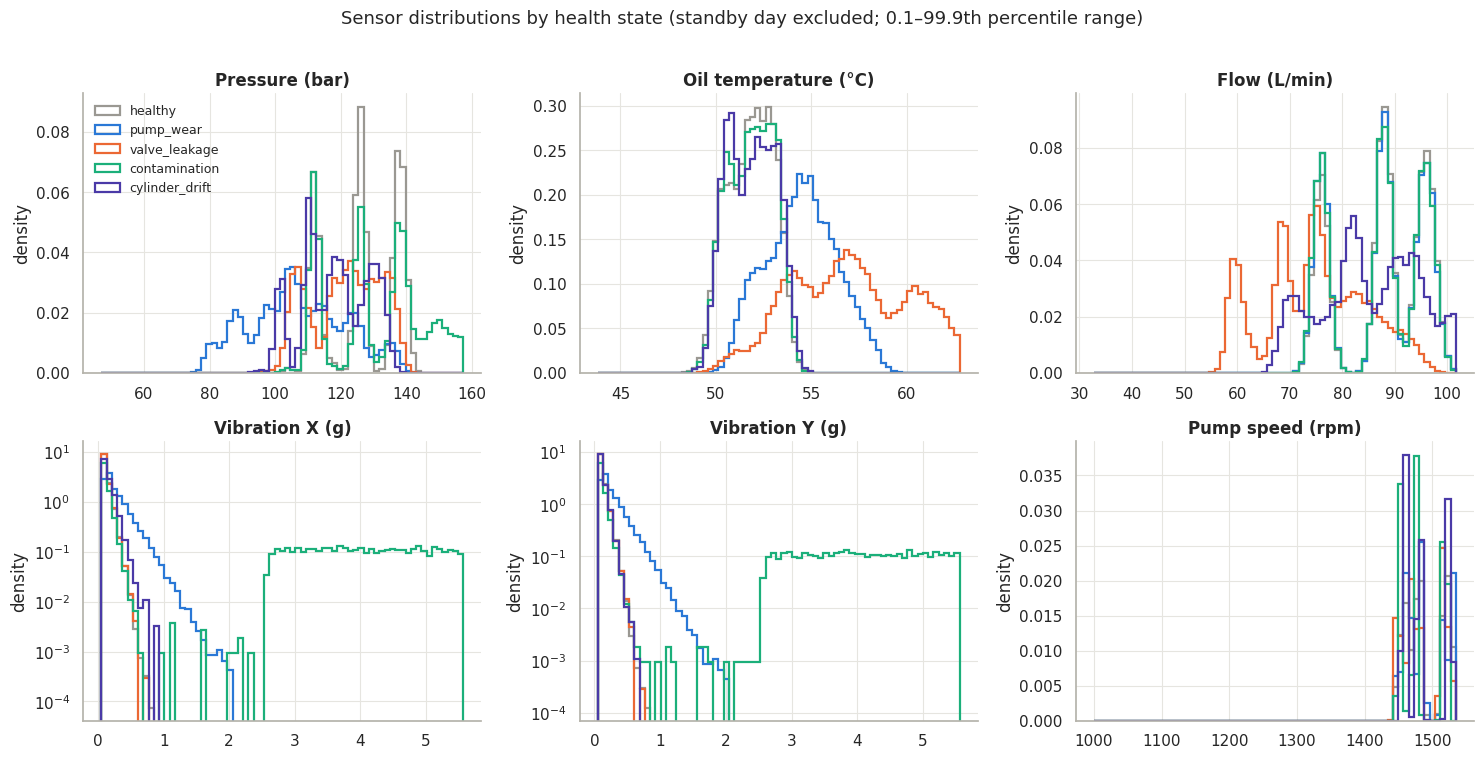

In [19]:
order = ["healthy"] + MODES
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, s in zip(axes.flat, SENSORS):
    lo, hi = df[s].quantile([0.001, 0.999])
    bins = np.linspace(lo, hi, 70)
    for st in order:
        v = df.loc[(df.state == st) & ~df.is_standby, s].dropna()
        ax.hist(v, bins=bins, density=True, histtype="step", lw=1.6, color=MODE_COLORS[st], label=st)
    ax.set(title=SENSOR_LABELS[s], ylabel="density")
    if s.startswith("vibration"): ax.set_yscale("log")
axes[0, 0].legend(fontsize=9)
fig.suptitle("Sensor distributions by health state (standby day excluded; 0.1–99.9th percentile range)", y=1.01, fontsize=13)
plt.tight_layout(); save(fig, "05_distributions"); plt.show()

**Findings: distributions**

- **Pressure, flow and temperature are multi-modal even for healthy machines.** Each operating regime (Day, Night, Weekend, see §7) runs at its own set point, roughly 138 / 126 / 112 bar. A single global threshold such as "pressure < 115 bar = fault" would raise a false alarm every weekend.
- **Vibration is strongly right-skewed** (heavy tail, kurtosis > 200). Log-transformed or quantile-based features will suit it better than raw means. Contamination produces a separate cluster of 2.5–15 g impacts that never occurs otherwise.
- Some failure modes separate visibly on a single sensor: **valve leakage** moves flow down and temperature up, **pump wear** moves pressure down and temperature and vibration up. **Cylinder drift** overlaps heavily with healthy data on every raw sensor, so it is the class most likely to need regime-normalised or X−Y features.
- `pump_rpm` distributions look the same for every state once the standby day is excluded. **Rpm reflects the operating command, not machine health.**

In [20]:
# How is the `shift` column defined? Hours and weekdays covered by each value
shift_def = tel.assign(hour=tel.timestamp.dt.hour).groupby("shift", observed=True).agg(
    hours=("hour", lambda h: sorted(h.unique())), weekdays=("day_of_week", lambda d: sorted(d.unique())))
shift_def.loc[SHIFT_ORDER]

,hours,weekdays
shift,,
Day,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]","[0, 1, 2, 3, 4]"
Night,"[0, 1, 2, 3, 4, 5, 6, 7, 20, 21, 22, 23]","[0, 1, 2, 3, 4]"
Weekend,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[5, 6]"


**Finding.** `shift` is a **deterministic calendar field**: *Day* = 08:00–19:59 and *Night* = 20:00–07:59 on Mon–Fri (0 = Monday), and *Weekend* = all of Sat–Sun. It can be derived from the timestamp, so it carries no information beyond `hour` and `day_of_week`. It is, however, a convenient proxy for **operating regime**.

## 6. Target analysis: failure mode and RUL

The project needs two targets: a **failure-mode class** and **RUL in hours**. Both were supplied already joined into the telemetry. Before any modelling we need to know exactly how they were built.

### 6.1 `is_anomaly` vs `failure_mode`: a leakage check

In [21]:
display(pd.crosstab(tel.is_anomaly, tel.failure_mode.astype(str).replace("nan", "— none —")))

failure_mode,contamination,cylinder_drift,pump_wear,valve_leakage,— none —
is_anomaly,,,,,
0,0,0,0,0,737280
1,14400,11520,57600,43200,0


**Finding.** `is_anomaly = 1` **exactly when** `failure_mode` is set. It is not an independent anomaly detector output; it is the binary version of the failure label. **It must never be used as an input feature** (target leakage). It can serve as the binary target for a "degradation vs healthy" detection model.

### 6.2 Class balance at row and event level

In [22]:
row_bal = df["state"].value_counts().to_frame("rows")
row_bal["pct"] = 100 * row_bal.rows / row_bal.rows.sum()
evt = fail.assign(window_days=(fail.failure_timestamp - fail.degradation_start_timestamp).dt.days)
evt_bal = evt.groupby("failure_mode").agg(events=("machine_id", "size"), machines=("machine_id", list),
                                          window_days=("window_days", "mean"))
display(row_bal); display(evt_bal)

,rows,pct
state,,
healthy,525600,60.833
post_failure,211680,24.500
pump_wear,57600,6.667
valve_leakage,43200,5.000
contamination,14400,1.667
cylinder_drift,11520,1.333


,events,machines,window_days
failure_mode,,,
contamination,2,"[HPU_03, HPU_09]",5.000
cylinder_drift,1,[HPU_06],8.000
pump_wear,3,"[HPU_01, HPU_04, HPU_08]",13.333
valve_leakage,3,"[HPU_02, HPU_05, HPU_07]",10.000


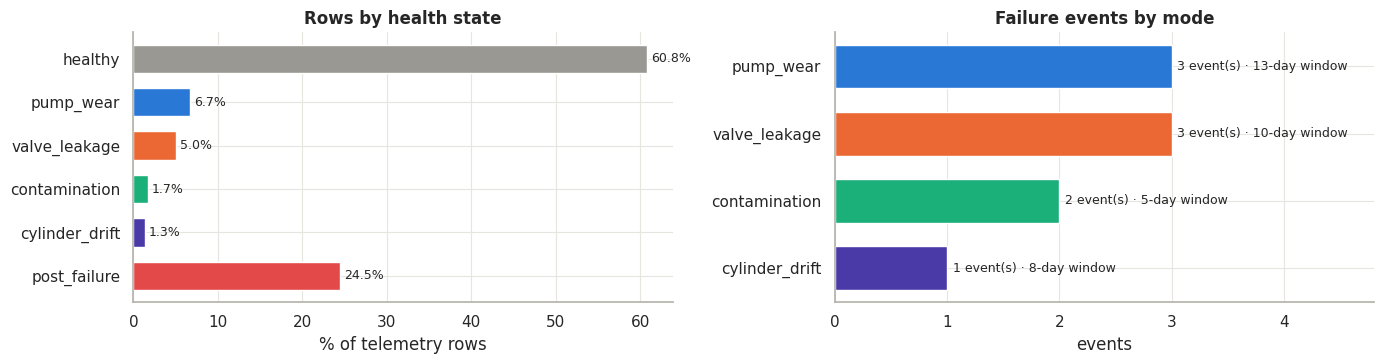

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
rb = row_bal.reindex(["healthy"] + MODES + ["post_failure"])
axes[0].barh(rb.index, rb.pct, color=[MODE_COLORS[i] for i in rb.index], height=0.65)
for y, v in enumerate(rb.pct): axes[0].text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=9)
axes[0].invert_yaxis(); axes[0].set(title="Rows by health state", xlabel="% of telemetry rows")
eb = evt_bal.reindex(MODES)
axes[1].barh(eb.index, eb.events, color=[MODE_COLORS[i] for i in eb.index], height=0.65)
for y, (n, w) in enumerate(zip(eb.events, eb.window_days)):
    axes[1].text(n + 0.05, y, f"{n} event(s) · {w:.0f}-day window", va="center", fontsize=9)
axes[1].invert_yaxis(); axes[1].set(title="Failure events by mode", xlabel="events", xlim=(0, 4.8))
plt.tight_layout(); save(fig, "06_class_balance"); plt.show()

**Findings: class balance**

- At row level, **61% of rows are healthy (before failure), 24.5% come after a failure** (repaired machines, see §6.3) and each failure mode has only 1.3–6.7% of rows.
- The more important constraint is at **event level: only 9 run-to-failure episodes**, one per machine (HPU_10 never fails and serves as a healthy reference). Contamination has 2 events and **cylinder drift only 1**. Hundreds of thousands of rows do not make up for that. Rows from the same episode are highly correlated, so the effective sample size is closer to 9 than to 864k.
- Each mode also has its own **degradation window length** (pump wear 12–14 d, valve leakage 10 d, cylinder drift 8 d, contamination 5 d). A fixed "failure in next N days" horizon will therefore behave differently per class.

**Implication for Stage 2:** a random row-level train/test split would leak neighbouring minutes of the same episode into both sets and produce wildly optimistic scores. Validation must be **grouped by machine/episode** (leave-one-machine-out), and results for cylinder drift must be reported with an explicit small-sample caveat.

### 6.3 How the supplied RUL target is constructed

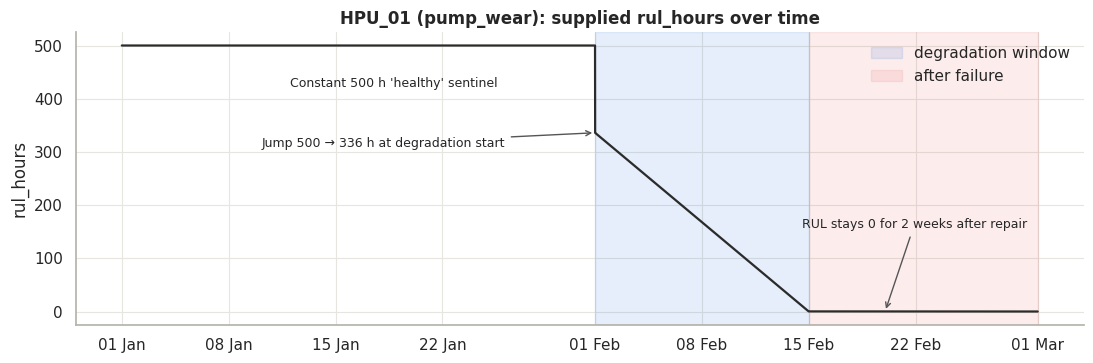

In [24]:
m = "HPU_01"; d = df[df.machine_id == m]
ev = fail.set_index("machine_id").loc[m]
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(d.timestamp, d.rul_hours, color="#2b2b2b", lw=1.6)
ax.axvspan(ev.degradation_start_timestamp, ev.failure_timestamp, color=MODE_COLORS["pump_wear"], alpha=0.12, label="degradation window")
ax.axvspan(ev.failure_timestamp, d.timestamp.max(), color=MODE_COLORS["post_failure"], alpha=0.10, label="after failure")
ax.annotate("Constant 500 h 'healthy' sentinel", (pd.Timestamp("2024-01-12"), 500), xytext=(0, -30), textcoords="offset points", fontsize=9)
ax.annotate("Jump 500 → 336 h at degradation start", (ev.degradation_start_timestamp, 336), xytext=(-240, -10), textcoords="offset points",
            fontsize=9, arrowprops=dict(arrowstyle="->", color="#555"))
ax.annotate("RUL stays 0 for 2 weeks after repair", (pd.Timestamp("2024-02-20"), 0), xytext=(-60, 60), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#555"))
ax.set(title=f"{m} ({ev.failure_mode}): supplied rul_hours over time", ylabel="rul_hours")
ax.legend(loc="upper right"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
save(fig, "06_rul_construction"); plt.show()

In [25]:
# Check the supplied RUL against the true time-to-failure, per region
win = df[df.state.isin(MODES)]
err = (win.rul_hours - win.hours_to_failure).abs()
print(f"Inside degradation windows, |rul_hours - true hours to failure|: median {err.median():.2f} h, max {err.max():.2f} h")
post = df[df.state == "post_failure"]
print(f"Post-failure rows with rul_hours == 0 : {(post.rul_hours == 0).mean():.0%} ({len(post):,} rows)")
pre = df[(df.state == "healthy") & df.failure_timestamp.notna()]
print(f"Pre-degradation rows at 500-h sentinel : {(pre.rul_hours == 500).mean():.0%}; "
      f"true hours to failure there ranges {pre.hours_to_failure.min():.0f}–{pre.hours_to_failure.max():.0f} h")

# Do sensors after failure look healthy again (i.e. the machine was repaired)?
cmp = df[df.machine_id != "HPU_10"].groupby("state")[["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g"]].median()
display(cmp.loc[["healthy", "post_failure"] + MODES])

Inside degradation windows, |rul_hours - true hours to failure|: median 0.03 h, max 0.05 h
Post-failure rows with rul_hours == 0 : 100% (211,680 rows)
Pre-degradation rows at 500-h sentinel : 100%; true hours to failure there ranges 120–1392 h


,pressure_bar,temp_celsius,flow_lpm,vibration_x_g
state,,,,
healthy,126.270,51.850,88.340,0.084
post_failure,126.520,52.240,88.580,0.084
pump_wear,106.110,54.530,88.275,0.197
valve_leakage,122.485,56.940,74.820,0.084
contamination,134.480,51.940,88.280,0.146
cylinder_drift,118.060,51.890,85.825,0.109


**Findings: the supplied RUL target is not usable as it is (DQ-07, critical)**

1. **Inside degradation windows RUL is correct**: it equals the true hours to failure to within about 1 h.
2. **Before degradation starts, RUL is a flat 500 h sentinel**, even though the true time to failure ranges from **120 h to about 1,400 h**. So the label says "500 h left" for machines that are only 5 days from failure. At degradation start the value then **jumps discontinuously** (for example 500 → 336 h). It is effectively a *piecewise-linear capped* target with an inconsistent cap.
3. **After failure, RUL stays at 0 for up to ~2 weeks**, while sensor readings return to healthy levels (the machine was repaired). A regressor trained on these rows would learn "healthy readings ⇒ RUL 0", the exact opposite of the truth.

**Recommendation for Stage 2:** rebuild the RUL target from `failure_labels.csv`:
`RUL = min(hours_to_failure, CAP)` with a single consistent cap (for example 336 h = 14 days, the longest degradation window), **exclude post-failure rows** from RUL training (or treat them as a new, censored life cycle), and treat HPU_10 as **right-censored** (no failure observed). This is the standard piecewise-linear RUL formulation used in the NASA C-MAPSS benchmark literature.

### 6.4 Consistency between the telemetry labels and the failure table

In [26]:
lab = (tel[tel.failure_mode.notna()].groupby("machine_id", observed=True)
       .agg(tel_mode=("failure_mode", "first"), tel_start=("timestamp", "min"), tel_end=("timestamp", "max")))
chk = fail.set_index("machine_id")[["failure_mode", "degradation_start_timestamp", "failure_timestamp"]].join(lab)
chk["mode_match"] = chk.failure_mode == chk.tel_mode.astype(str)
chk["start_match"] = chk.degradation_start_timestamp == chk.tel_start
chk["end_is_minute_before_failure"] = chk.failure_timestamp - chk.tel_end == pd.Timedelta("1min")
chk

,failure_mode,degradation_start_timestamp,failure_timestamp,tel_mode,tel_start,tel_end,mode_match,start_match,end_is_minute_before_failure
machine_id,,,,,,,,,
HPU_01,pump_wear,2024-02-01,2024-02-15,pump_wear,2024-02-01,2024-02-14 23:59:00,True,True,True
HPU_02,valve_leakage,2024-02-12,2024-02-22,valve_leakage,2024-02-12,2024-02-21 23:59:00,True,True,True
HPU_03,contamination,2024-02-03,2024-02-08,contamination,2024-02-03,2024-02-07 23:59:00,True,True,True
HPU_04,pump_wear,2024-02-16,2024-02-28,pump_wear,2024-02-16,2024-02-27 23:59:00,True,True,True
HPU_05,valve_leakage,2024-01-21,2024-01-31,valve_leakage,2024-01-21,2024-01-30 23:59:00,True,True,True
HPU_06,cylinder_drift,2024-02-10,2024-02-18,cylinder_drift,2024-02-10,2024-02-17 23:59:00,True,True,True
HPU_07,valve_leakage,2024-02-15,2024-02-25,valve_leakage,2024-02-15,2024-02-24 23:59:00,True,True,True
HPU_08,pump_wear,2024-01-29,2024-02-12,pump_wear,2024-01-29,2024-02-11 23:59:00,True,True,True
HPU_09,contamination,2024-01-21,2024-01-26,contamination,2024-01-21,2024-01-25 23:59:00,True,True,True


**Finding.** The labels in the telemetry file agree exactly with `failure_labels.csv` (mode, window start and end) for all 9 events. The failure table is a reliable source for rebuilding targets.

## 7. Temporal patterns and operating regimes

### 7.1 Fleet overview: daily health heatmap

Each cell is a machine's **daily median**, expressed as a z-score against that machine's own healthy January behaviour. Normalising per machine removes differences between units (installation, calibration), so drift shows up as colour. The black box marks each machine's labelled degradation window.

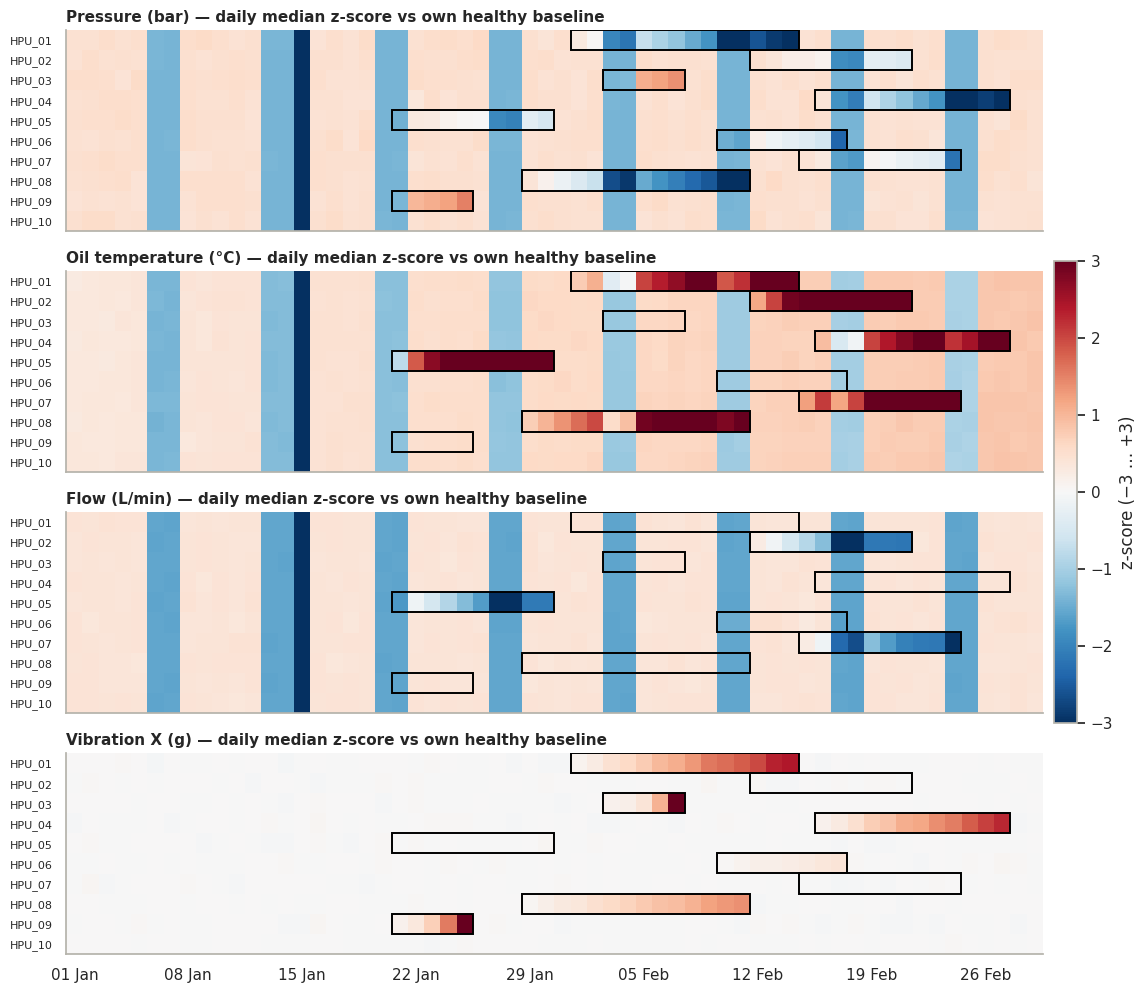

In [27]:
# Reference period: 1–20 Jan (before any degradation starts), excluding the standby day
base = df[(df.timestamp < "2024-01-21") & ~df.is_standby]
mu = base.groupby("machine_id", observed=True)[SENSORS].median()
sd = base.groupby("machine_id", observed=True)[SENSORS].std()

daily = df.set_index("timestamp").groupby("machine_id", observed=True)[SENSORS].resample("1D").median()
daily_z = (daily - mu.reindex(daily.index.get_level_values(0)).values) / sd.reindex(daily.index.get_level_values(0)).values

show = ["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g"]
fig, axes = plt.subplots(len(show), 1, figsize=(15, 12), sharex=True)
days = daily_z.index.get_level_values(1).unique()
for ax, s in zip(axes, show):
    mat = daily_z[s].unstack(level=1)
    im = ax.imshow(mat.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, interpolation="nearest")
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_title(f"{SENSOR_LABELS[s]} — daily median z-score vs own healthy baseline", loc="left", fontsize=11)
    ax.grid(False)
    for i, mid in enumerate(mat.index):
        if mid in fail.machine_id.values:
            e = fail.set_index("machine_id").loc[mid]
            x0 = (e.degradation_start_timestamp - days[0]).days - 0.5
            x1 = (e.failure_timestamp - days[0]).days - 0.5
            ax.add_patch(plt.Rectangle((x0, i - 0.5), x1 - x0, 1, fill=False, ec="black", lw=1.4))
ticks = range(0, len(days), 7)
axes[-1].set_xticks(list(ticks)); axes[-1].set_xticklabels([days[t].strftime("%d %b") for t in ticks])
fig.colorbar(im, ax=axes, shrink=0.5, label="z-score (−3 … +3)", pad=0.01)
save(fig, "07_fleet_heatmap"); plt.show()

**Findings: fleet overview**

- **Degradation is visible and gradual:** colour builds up inside the boxes and peaks just before failure. Pump-wear machines (HPU_01/04/08) show falling pressure, valve-leakage machines (HPU_02/05/07) show falling flow and rising temperature, and contamination machines (HPU_03/09) show a vibration burst.
- **Vertical stripes that recur weekly** (lighter pressure and flow on every machine at the same time) are **weekend load reductions**, not faults. Features must therefore be regime-aware (§7.2).
- The **dark-blue column on 15 Jan** is the fleet-wide standby day from §4.4. On raw levels it looks like 10 simultaneous failures.
- After failure, the rows return to neutral, which confirms the repair and the post-failure RUL problem in §6.3.

### 7.2 Operating regimes: shift and weekend effects on healthy machines

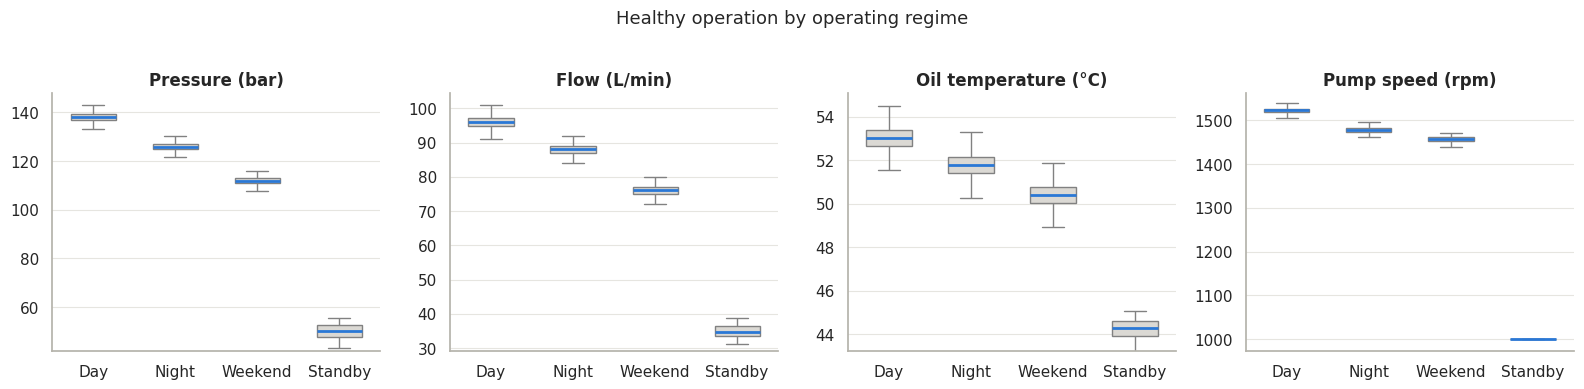

,pressure_bar,flow_lpm,temp_celsius,pump_rpm
regime,,,,
Day,138.000,96.000,53.000,"1,523.000"
Night,125.920,88.010,51.770,"1,479.000"
Weekend,111.960,76.010,50.400,"1,458.000"
Standby,50.090,34.805,44.260,"1,000.000"


In [28]:
hb = df[df.state == "healthy"]
REGIME_ORDER = SHIFT_ORDER + ["Standby"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, s in zip(axes, ["pressure_bar", "flow_lpm", "temp_celsius", "pump_rpm"]):
    sns.boxplot(data=hb, x="regime", y=s, order=REGIME_ORDER, ax=ax, color="#dcdad3", fliersize=0, width=0.55,
                medianprops=dict(color=MODE_COLORS["pump_wear"], lw=2))
    lo, hi = hb[s].quantile([0.001, 0.999]); ax.set_ylim(lo - (hi - lo) * 0.05, hi + (hi - lo) * 0.05)
    ax.set(title=SENSOR_LABELS[s], xlabel="", ylabel="")
fig.suptitle("Healthy operation by operating regime", y=1.02, fontsize=13)
plt.tight_layout(); save(fig, "07_regimes"); plt.show()
display(hb.groupby("regime")[["pressure_bar", "flow_lpm", "temp_celsius", "pump_rpm"]].median().reindex(REGIME_ORDER))

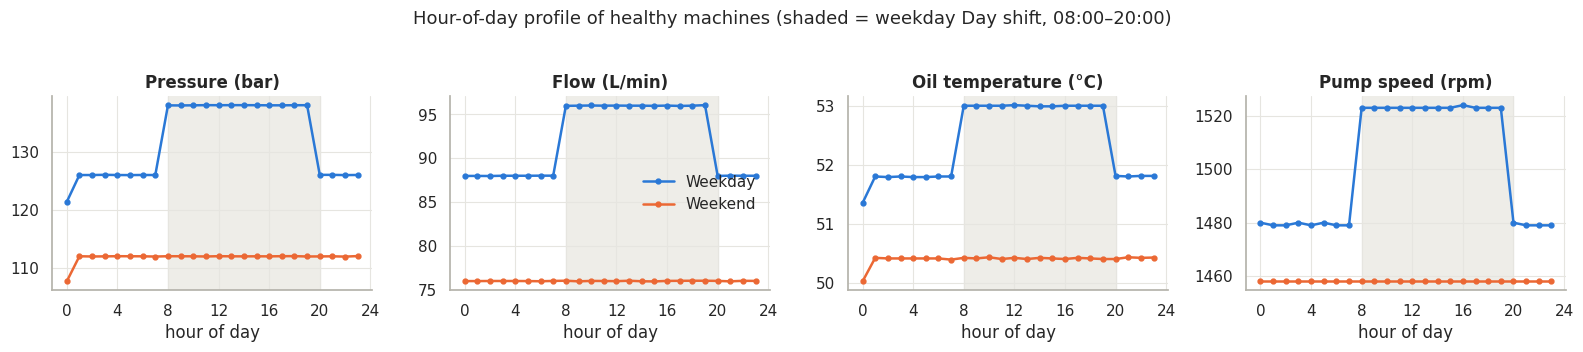

In [29]:
# Daily cycle within weekdays (healthy data, fleet median by hour of day)
prof = (hb[~hb.is_standby].groupby(["day_type", "hour"])[["pressure_bar", "flow_lpm", "temp_celsius", "pump_rpm"]]
        .median())
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, s in zip(axes, prof.columns):
    for dt, c in [("Weekday", MODE_COLORS["pump_wear"]), ("Weekend", MODE_COLORS["valve_leakage"])]:
        ax.plot(prof.loc[dt].index, prof.loc[dt, s], color=c, marker="o", ms=3.5, label=dt)
    ax.axvspan(8, 20, color="#eeede8", zorder=0); ax.set(title=SENSOR_LABELS[s], xlabel="hour of day", xticks=range(0, 25, 4))
axes[1].legend(loc="center right")
fig.suptitle("Hour-of-day profile of healthy machines (shaded = weekday Day shift, 08:00–20:00)", y=1.03, fontsize=13)
plt.tight_layout(); save(fig, "07_hour_profile"); plt.show()

**Findings: operating regimes**

- There are **four operating regimes** with distinct set points: **Day** (~138 bar / 96 L/min / 1,523 rpm), **Night** (~126 bar / 88 L/min / 1,479 rpm), **Weekend** (~112 bar / 76 L/min / 1,458 rpm) and the one-off **Standby** day (~50 bar / 35 L/min / 1,000 rpm). The steps happen exactly at 08:00 and 20:00.
- There is also a **short low-load hour every day at 00:00–00:59** (about −4 to −5 bar, with slightly cooler oil), probably a scheduled midnight cycle such as a tool change or flush. It is small, but it is a false-alarm risk for any fixed threshold.
- `pump_rpm` simply follows the regime, so it reflects **the operating command, not machine condition**.
- **Implication:** raw-level features confuse "weekend" or "midnight" with "degradation". Stage 2 should compute **regime-normalised residuals**: the deviation from the machine's own healthy baseline *for the same day type and hour*. §8 does exactly that and the failure fingerprints become clean.

### 7.3 Autocorrelation: how much memory do the signals have?

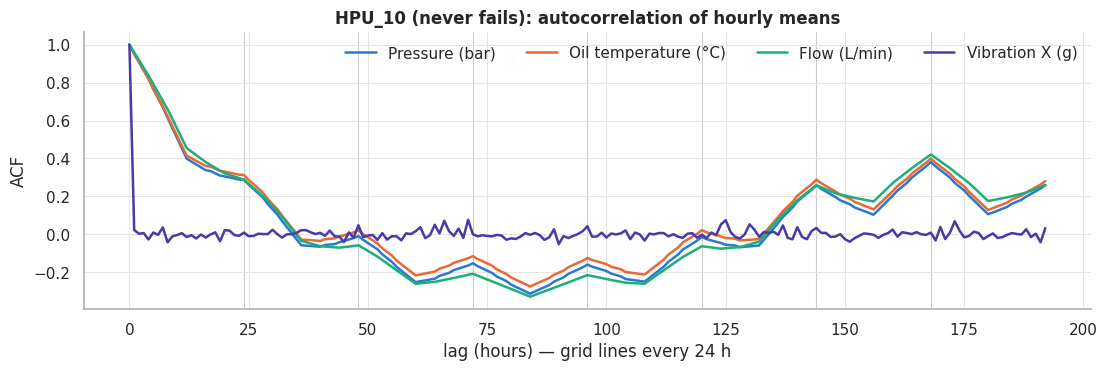

In [30]:
h = df[(df.machine_id == "HPU_10")].set_index("timestamp")[["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g"]].resample("1h").mean()
fig, ax = plt.subplots(figsize=(13, 3.6))
for s, c in zip(h.columns, [MODE_COLORS[m] for m in MODES]):
    ax.plot(acf(h[s].interpolate(), nlags=24 * 8), label=SENSOR_LABELS[s], color=c)
for d_ in range(1, 8): ax.axvline(24 * d_, color="#cccccc", lw=0.8, zorder=0)
ax.set(title="HPU_10 (never fails): autocorrelation of hourly means", xlabel="lag (hours) — grid lines every 24 h", ylabel="ACF")
ax.legend(ncol=4, loc="upper right"); save(fig, "07_acf"); plt.show()

**Finding.** Pressure, flow and temperature show strong **daily (24 h) and weekly (168 h) periodicity** from the shift pattern, while vibration behaves close to white noise during healthy operation. This confirms that (a) regime or calendar context must be included in features, and (b) minute-level rows are heavily autocorrelated. That is a second reason why row-level random splits and naive p-values overstate certainty.

## 8. Failure signatures and early-warning lead time

### 8.1 Regime-normalised degradation trajectories

Section 7 showed that most of the variance in healthy data comes from the operating regime. To take it out, we build a **healthy baseline for each machine × day type (weekday or weekend) × hour of day**, using 1–20 Jan (before any degradation starts, standby day excluded). Every reading is then expressed as:

- a **% deviation** from that baseline, which is easy for engineers to read ("pressure is 25% low"), and
- a **z-score** (deviation ÷ baseline standard deviation), which is used for thresholds.

The plot shows the fleet median trajectory of each failure mode over the 20 days before failure. This is the view that tells us *which sensors to engineer features from* and *how early the signal appears*.

In [31]:
KEY = ["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g", "vibration_y_g"]
ref = df[(df.timestamp < "2024-01-21") & ~df.is_standby]
ref_keys = [ref.machine_id.astype(str), ref.day_type, ref.hour]
bmu = ref.groupby(ref_keys)[KEY].median()
bsd = ref.groupby(ref_keys)[KEY].std()
idx = pd.MultiIndex.from_arrays([df.machine_id.astype(str), df.day_type, df.hour])
MU, SD = bmu.reindex(idx).to_numpy(), bsd.reindex(idx).to_numpy()   # standby rows have no baseline → NaN
for i, k in enumerate(KEY):
    df[f"z_{k}"] = (df[k].to_numpy() - MU[:, i]) / SD[:, i]
    df[f"pct_{k}"] = 100 * (df[k].to_numpy() / MU[:, i] - 1)
df["vib_xy_delta"] = df.vibration_x_g - df.vibration_y_g
df["z_vib_xy_delta"] = df.vib_xy_delta / (ref.vibration_x_g - ref.vibration_y_g).std()
print("Baseline cells:", len(bmu), "(machines × day types × hours)")
print("Median baseline std on weekdays — pressure {:.2f} bar, flow {:.2f} L/min, temp {:.2f} °C".format(
      *bsd.xs("Weekday", level=1)[["pressure_bar", "flow_lpm", "temp_celsius"]].median()))

Baseline cells: 480 (machines × day types × hours)
Median baseline std on weekdays — pressure 1.74 bar, flow 1.63 L/min, temp 0.53 °C


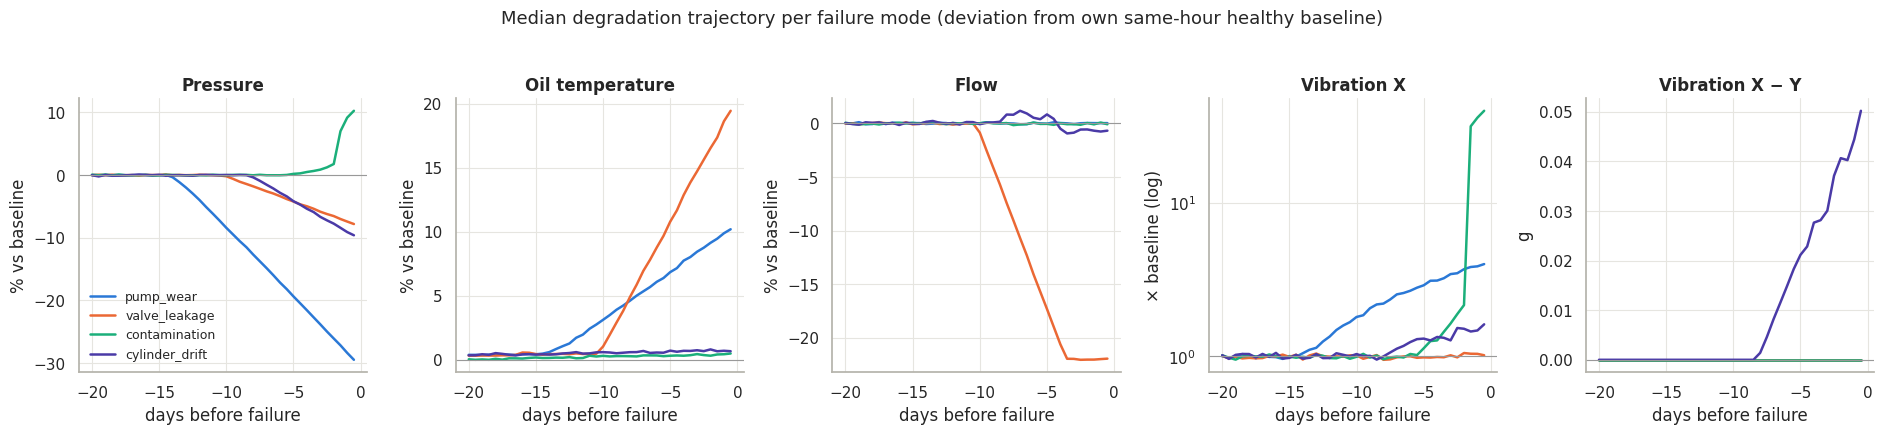

In [32]:
pre = df[df.failure_timestamp.notna() & (df.hours_to_failure > 0) & (df.hours_to_failure <= 20 * 24)].copy()
pre["mode"] = pre.machine_id.astype(str).map(fail.set_index("machine_id").failure_mode)
pre["days_before"] = -np.ceil(pre.hours_to_failure / 12) * 12 / 24      # 12-hour bins
traj = pre.groupby(["mode", "days_before"])[["pct_pressure_bar", "pct_temp_celsius", "pct_flow_lpm", "pct_vibration_x_g", "vib_xy_delta"]].median()

panels = [("pct_pressure_bar", "Pressure", "% vs baseline"), ("pct_temp_celsius", "Oil temperature", "% vs baseline"),
          ("pct_flow_lpm", "Flow", "% vs baseline"), ("pct_vibration_x_g", "Vibration X", "× baseline (log)"),
          ("vib_xy_delta", "Vibration X − Y", "g")]
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharex=True)
for ax, (col, title, unit) in zip(axes, panels):
    for mode in MODES:
        t = traj.loc[mode, col]
        y = 1 + t / 100 if col == "pct_vibration_x_g" else t
        ax.plot(t.index, y, color=MODE_COLORS[mode], label=mode)
    if col == "pct_vibration_x_g":
        ax.set_yscale("log"); ax.axhline(1, color="#999", lw=0.8)
    else:
        ax.axhline(0, color="#999", lw=0.8)
    ax.set(title=title, xlabel="days before failure", ylabel=unit)
axes[0].legend(fontsize=9, loc="lower left")
fig.suptitle("Median degradation trajectory per failure mode (deviation from own same-hour healthy baseline)", y=1.03, fontsize=13)
plt.tight_layout(); save(fig, "08_trajectories"); plt.show()

In [33]:
# The same numbers as a table: change at 10, 5, 2 days and in the final 12 h before failure
snap = traj.loc[(slice(None), [-10.0, -5.0, -2.0, -0.5]), :].round({c: 1 for c in traj.columns[:4]} | {"vib_xy_delta": 3})
snap.columns = ["pressure %", "temp %", "flow %", "vib X %", "vib X−Y (g)"]
snap.index.names = ["failure_mode", "days before failure"]
snap

pressure %  temp %  flow %   vib X %  vib X−Y (g)
failure_mode   days before failure                                                   
contamination  -10.000                  -0.000   0.300   0.000    -0.600        0.000
               -5.000                    0.200   0.300  -0.000    13.000        0.000
               -2.000                    1.800   0.300   0.000   115.800        0.000
               -0.500                   10.300   0.500  -0.100 3,873.600        0.000
cylinder_drift -10.000                   0.000   0.600  -0.100     3.600        0.000
               -5.000                   -4.200   0.700   0.800    30.600        0.021
               -2.000                   -7.700   0.800  -0.600    51.400        0.041
               -0.500                   -9.600   0.700  -0.700    61.800        0.050
pump_wear      -10.000                  -8.400   3.100   0.000    80.600        0.000
               -5.000                  -19.400   6.800  -0.000   190.400        0.000
               -2.000                  -26.100   9.100   0.000   269.800        0.000
               -0.500                  -29.500  10.200   0.000   299.100        0.000
valve_leakage  -10.000                  -0.200   1.000  -0.900     1.500        0.000
               -5.000                   -4.200  10.800 -17.300    -1.400        0.000
               -2.000                   -6.500  16.500 -22.000     5.200        0.000
               -0.500                   -7.800  19.500 -22.000     1.800        0.000

**Findings: each failure mode has a distinct, physically sensible fingerprint**

| Failure mode | Primary signature | Secondary | Onset | Physical interpretation |
|---|---|---|---|---|
| **Pump wear** | Pressure falls steadily (≈ −30% at failure) | Vibration ×4, temperature +10% | ~13 days, linear | Internal leakage in a worn pump lowers volumetric efficiency; bearing wear adds vibration |
| **Valve leakage** | Flow falls (≈ −22%) | Temperature rises sharply (≈ +20%, about +10 °C), pressure −8% | ~9 days | Fluid bypassing the valve is throttled, converting pressure energy to heat |
| **Contamination** | Vibration explodes (×30–40) | Pressure +10%, X/Y axes diverge | Only the last ~2 days | Particles cause abrasion and sticking, which shows up as impulsive vibration late in the process |
| **Cylinder drift** | Vibration X diverges from Y | Pressure −10%, vibration X +60% | ~7 days | Asymmetric loading on one axis; almost invisible on raw sensor levels |

With regime normalisation the trajectories are **smooth and nearly monotonic**. The weekend and midnight saw-tooth pattern in the raw data disappears completely. **Regime-normalised residuals should be the core feature family in Stage 2**, and the near-linear degradation of pump wear and valve leakage is good news for RUL regression.

### 8.2 Fingerprint matrix: last 48 hours before failure

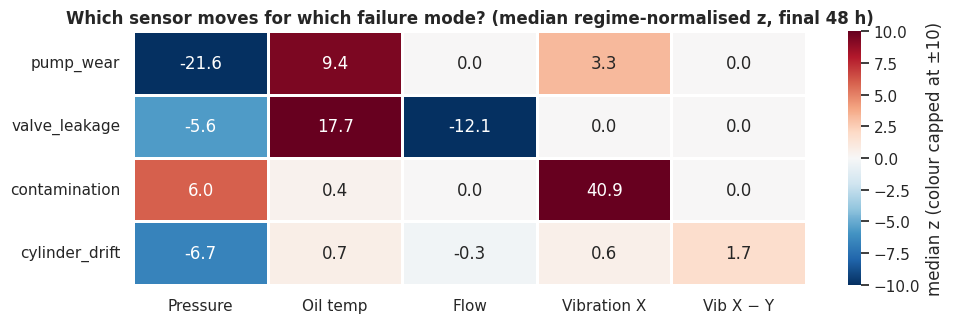

In [34]:
zcols = {"z_pressure_bar": "Pressure", "z_temp_celsius": "Oil temp", "z_flow_lpm": "Flow",
         "z_vibration_x_g": "Vibration X", "z_vib_xy_delta": "Vib X − Y"}
last48 = pre[pre.hours_to_failure <= 48].groupby("mode")[list(zcols)].median().rename(columns=zcols).reindex(MODES)
fig, ax = plt.subplots(figsize=(10, 3.4))
sns.heatmap(last48.clip(-10, 10).astype(float), annot=last48.astype(float).to_numpy(), fmt=".1f", cmap="RdBu_r", center=0, vmin=-10, vmax=10,
            cbar_kws={"label": "median z (colour capped at ±10)"}, linewidths=2, linecolor="white", ax=ax)
ax.set(title="Which sensor moves for which failure mode? (median regime-normalised z, final 48 h)", xlabel="", ylabel="")
plt.tight_layout(); save(fig, "08_fingerprint"); plt.show()

**Finding.** Each row of the matrix is dominated by a different sensor or sensor combination, so the four failure modes are **separable in principle**. That is good news for the classification objective. (The X−Y value for cylinder drift looks small as a z-score only because the healthy X−Y difference is almost always exactly zero. About 0.05 g of sustained divergence is unambiguous; see §8.4.)

- Pump wear and valve leakage both heat the oil, but differ sharply on **pressure vs flow**.
- Contamination is the only mode with **extreme vibration**.
- Cylinder drift is identified by the **X−Y divergence** together with a moderate pressure drop.

### 8.3 Early-warning lead time: a transparent rule-based baseline

**Business question:** *how much notice could a simple condition monitor give, and at what false-alarm cost?*

We apply five fleet-wide rules to every machine. Each rule needs its signal (6-hour rolling median) to stay beyond the threshold for **6 consecutive hours** before it raises an alarm:

| Rule | Signal | Alarm when |
|---|---|---|
| `pressure_low` | pressure z | < −3 |
| `flow_low` | flow z | < −3 |
| `temp_high` | temperature z | > +3 |
| `vibration_high` | vibration X z | > +3 |
| `xy_divergence` | 6-h mean of \|X − Y\| | > 0.02 g |

This is the **baseline that the Stage 2 ML models must beat**. We compare it with a *naive* detector that uses raw thresholds without regime normalisation.

In [35]:
RULES = {"pressure_low": ("z_pressure_bar", -1, 3.0), "flow_low": ("z_flow_lpm", -1, 3.0),
         "temp_high": ("z_temp_celsius", +1, 3.0), "vibration_high": ("z_vibration_x_g", +1, 3.0),
         "xy_divergence": ("vib_xy_delta", +1, 0.02)}

def sustained(mask, window="6h"):
    return mask.astype(int).rolling(window).min().eq(1)

frames = []
for mid, g in df.groupby("machine_id", observed=True):
    g = g.set_index("timestamp")
    A = pd.DataFrame(index=g.index)
    for name, (col, sign, thr) in RULES.items():
        sig = g[col].rolling("6h").mean().abs() if name == "xy_divergence" else g[col].rolling("6h").median() * sign
        A[name] = sustained(sig > thr) & ~g.is_standby
    # Naive comparison: raw pressure below (machine median − 3σ) using one all-regime baseline (from §7.1)
    A["naive_pressure_low"] = sustained(g.pressure_bar < mu.loc[mid, "pressure_bar"] - 3 * sd.loc[mid, "pressure_bar"])
    A["machine_id"], A["state"], A["is_standby"] = mid, g.state.values, g.is_standby.values
    frames.append(A.reset_index())
alarms = pd.concat(frames, ignore_index=True)
alarms["any_rule"] = alarms[list(RULES)].any(axis=1)

# Lead time per event: earliest alarm in the 30 days before failure, per rule and for any rule
rows = []
for _, e in fail.iterrows():
    a = alarms[(alarms.machine_id == e.machine_id) & alarms.timestamp.between(e.failure_timestamp - pd.Timedelta("30D"), e.failure_timestamp, inclusive="left")]
    r = {"machine_id": e.machine_id, "failure_mode": e.failure_mode,
         "window_h": (e.failure_timestamp - e.degradation_start_timestamp) / pd.Timedelta("1h")}
    for name in list(RULES) + ["any_rule"]:
        first = a.loc[a[name], "timestamp"].min()
        r[name] = (e.failure_timestamp - first) / pd.Timedelta("1h") if pd.notna(first) else 0.0
    r["first_rule"] = max(RULES, key=lambda n: r[n]) if r["any_rule"] > 0 else "—"
    rows.append(r)
lead = pd.DataFrame(rows).sort_values(["failure_mode", "machine_id"]).reset_index(drop=True)
lead.to_csv(REPORT_DIR / "baseline_lead_times.csv", index=False)
lead.round(0)

,machine_id,failure_mode,window_h,pressure_low,flow_low,temp_high,vibration_high,xy_divergence,any_rule,first_rule
0,HPU_03,contamination,120.000,0.000,0.000,0.000,20.000,82.000,82.000,xy_divergence
1,HPU_09,contamination,120.000,0.000,0.000,0.000,27.000,55.000,55.000,xy_divergence
2,HPU_06,cylinder_drift,192.000,109.000,0.000,0.000,0.000,122.000,122.000,xy_divergence
3,HPU_01,pump_wear,336.000,284.000,0.000,231.000,53.000,0.000,284.000,pressure_low
4,HPU_04,pump_wear,288.000,240.000,0.000,205.000,55.000,0.000,240.000,pressure_low
5,HPU_08,pump_wear,336.000,285.000,0.000,231.000,34.000,0.000,285.000,pressure_low
6,HPU_02,valve_leakage,240.000,107.000,189.000,200.000,0.000,0.000,200.000,temp_high
7,HPU_05,valve_leakage,240.000,111.000,189.000,194.000,0.000,0.000,194.000,temp_high
8,HPU_07,valve_leakage,240.000,112.000,191.000,203.000,0.000,0.000,203.000,temp_high


In [36]:
# False alarms: alarm-hours while the machine is healthy.
# The repair downtime right after each failure is excluded: the machine is not running, and the 6-h rolling
# windows there still contain pre-failure readings.
ev = fail.set_index("machine_id")
repair_end = alarms.machine_id.map(ev.failure_timestamp + pd.to_timedelta(ev.downtime_hours, unit="h"))
in_repair = (alarms.state == "post_failure") & (alarms.timestamp < repair_end)
healthy_rows = alarms.state.isin(["healthy", "post_failure"]) & ~in_repair
fa = pd.DataFrame({
    "healthy hours": [healthy_rows.sum() / 60] * 2,
    "alarm hours": [alarms.loc[healthy_rows, "any_rule"].sum() / 60, alarms.loc[healthy_rows, "naive_pressure_low"].sum() / 60],
    "machines alarmed on standby day": [alarms.loc[alarms.is_standby & alarms.any_rule, "machine_id"].nunique(),
                                        alarms.loc[alarms.is_standby & alarms.naive_pressure_low, "machine_id"].nunique()],
    "alarm hours on weekends": [alarms.loc[healthy_rows & (alarms.timestamp.dt.dayofweek >= 5), "any_rule"].sum() / 60,
                                alarms.loc[healthy_rows & (alarms.timestamp.dt.dayofweek >= 5), "naive_pressure_low"].sum() / 60],
}, index=["regime-aware rules (5 rules)", "naive raw pressure threshold"]).round(1)
fa

,healthy hours,alarm hours,machines alarmed on standby day,alarm hours on weekends
regime-aware rules (5 rules),"12,181.300",0.000,0,0.000
naive raw pressure threshold,"12,181.300",180.200,10,0.000


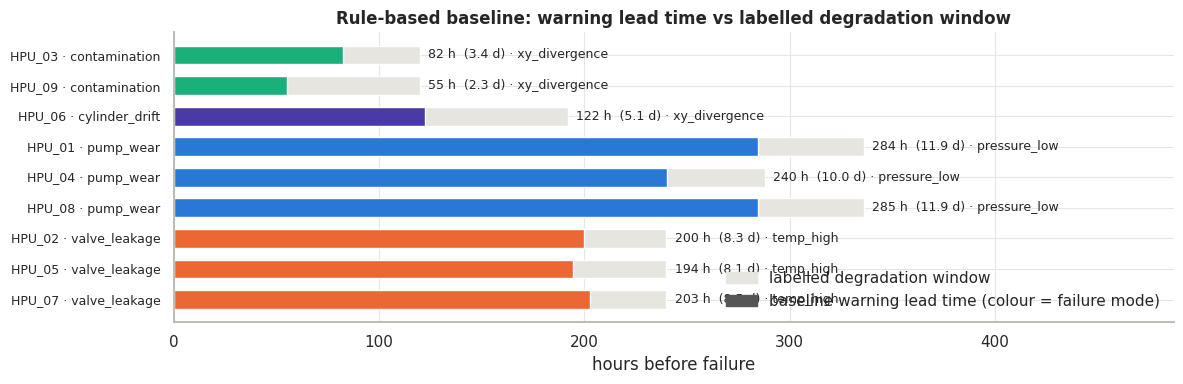

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(lead.index, lead.window_h, color="#e6e5e0", height=0.62, label="labelled degradation window")
ax.barh(lead.index, lead.any_rule, color=[MODE_COLORS[m] for m in lead.failure_mode], height=0.62, label="baseline warning lead time")
for i, r in lead.iterrows():
    ax.text(max(r.window_h, r.any_rule) + 4, i, f"{r.any_rule:.0f} h  ({r.any_rule/24:.1f} d) · {r.first_rule}", va="center", fontsize=9)
ax.set_yticks(lead.index); ax.set_yticklabels(lead.machine_id + " · " + lead.failure_mode, fontsize=9)
ax.invert_yaxis(); ax.set(xlabel="hours before failure", xlim=(0, lead.window_h.max() * 1.45),
                          title="Rule-based baseline: warning lead time vs labelled degradation window")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#e6e5e0"), plt.Rectangle((0, 0), 1, 1, color="#555555")],
          labels=["labelled degradation window", "baseline warning lead time (colour = failure mode)"], loc="lower right")
plt.tight_layout(); save(fig, "08_lead_time"); plt.show()

**Findings: lead time**

- With regime normalisation, a handful of transparent rules give **10–12 days of warning for pump wear, about 8 days for valve leakage and about 5 days for cylinder drift**. That is enough to order spare parts and move the repair into a planned maintenance window.
- **Contamination is the hard case.** The vibration-level rule fires only about 1 day before failure, but the **X−Y divergence rule fires 2–3 days ahead** (55–82 h). A multi-signal model should push this further.
- For valve leakage, the **temperature rule fires first** (about 8 days ahead), before flow drops enough to trip the flow rule.
- **False alarms:** across about 12,000 healthy machine-hours, the regime-aware rules raised **no alarms**: none at weekends and none on the standby day. The naive raw pressure threshold fires on **all 10 machines on the standby day**. Regime normalisation is what makes the difference.
- **Caveat:** thresholds were set by inspection and baselines were fitted on part of the same data (1–20 Jan). These numbers are in-sample and optimistic, and they are a **bar to beat**, not a validated performance claim. Stage 3 will evaluate models leave-one-machine-out.

### 8.4 Vibration axis divergence: the cylinder-drift signature

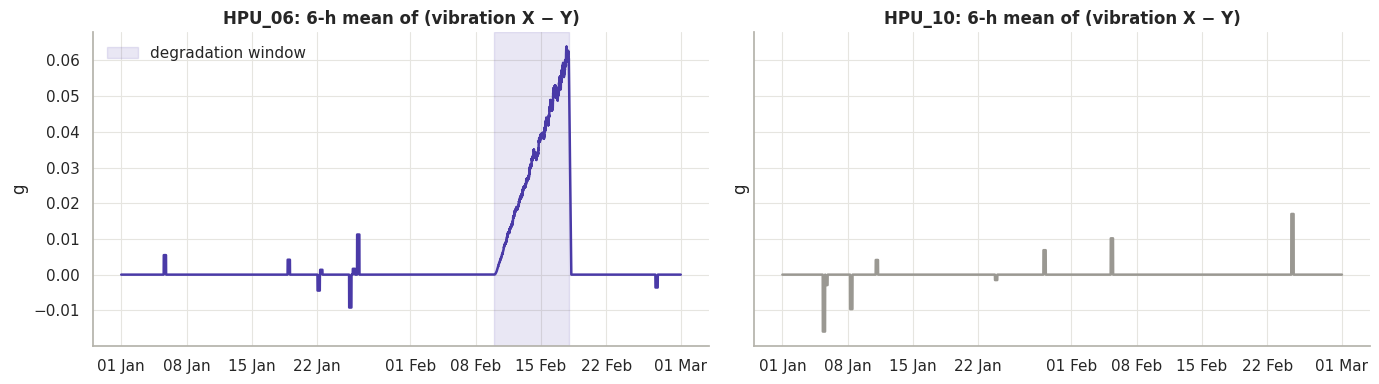

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for mid, ax in zip(["HPU_06", "HPU_10"], axes):
    d = df[df.machine_id == mid].set_index("timestamp")
    delta = (d.vibration_x_g - d.vibration_y_g).rolling("6h").mean()
    ax.plot(delta.index, delta, color=MODE_COLORS["cylinder_drift"] if mid == "HPU_06" else MODE_COLORS["healthy"])
    if mid in fail.machine_id.values:
        e = fail.set_index("machine_id").loc[mid]
        ax.axvspan(e.degradation_start_timestamp, e.failure_timestamp, color=MODE_COLORS["cylinder_drift"], alpha=0.12, label="degradation window")
        ax.legend(loc="upper left")
    ax.set(title=f"{mid}: 6-h mean of (vibration X − Y)", ylabel="g"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); save(fig, "08_xy_divergence"); plt.show()

**Finding.** On the cylinder-drift machine, the X−Y difference is essentially zero for six weeks and then rises clearly throughout the degradation window, while the healthy reference machine stays flat. A single engineered feature `vib_x − vib_y` turns the hardest class into a detectable one. (Both panels share the y-axis. The small blips on HPU_10 are isolated readings well below the 0.02 g alarm threshold.)

## 9. Multivariate relationships and statistical testing

### 9.1 Correlation structure: healthy vs degrading

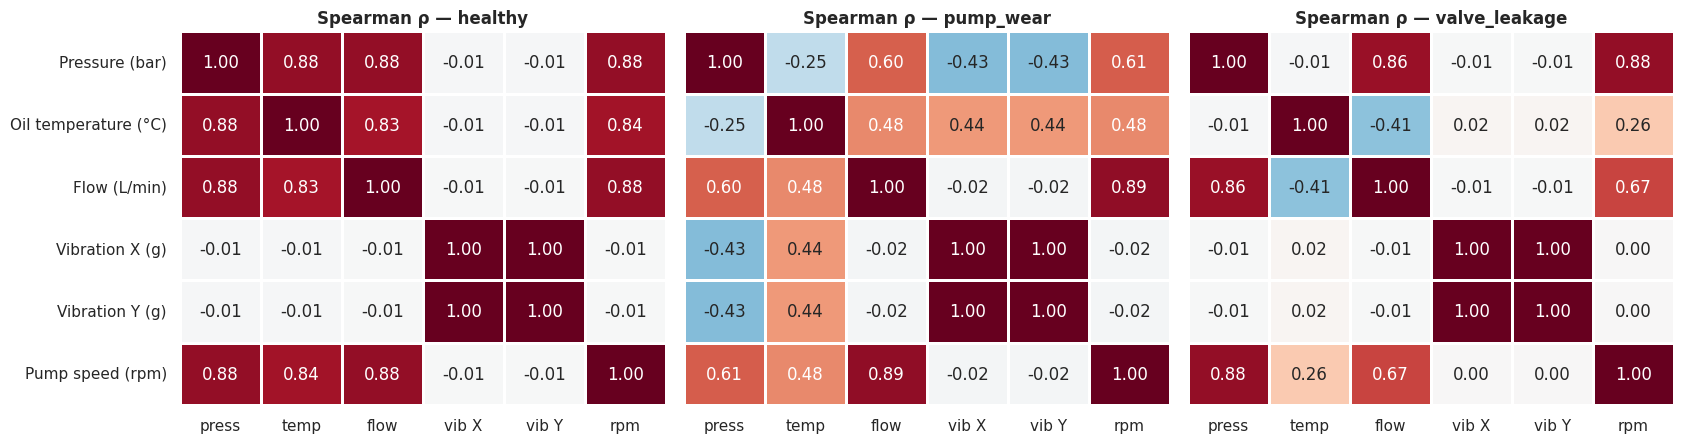

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
groups = [("healthy", (df.state == "healthy") & ~df.is_standby), ("pump_wear", df.state == "pump_wear"), ("valve_leakage", df.state == "valve_leakage")]
for ax, (name, mask) in zip(axes, groups):
    c = df.loc[mask, SENSORS].sample(100_000, random_state=RANDOM_STATE, replace=mask.sum() < 100_000).corr("spearman")
    sns.heatmap(c, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, cbar=False, ax=ax,
                xticklabels=["press", "temp", "flow", "vib X", "vib Y", "rpm"],
                yticklabels=[SENSOR_LABELS[s] for s in SENSORS] if ax is axes[0] else False, linewidths=1, linecolor="white")
    ax.set_title(f"Spearman ρ — {name}")
plt.tight_layout(); save(fig, "09_correlations"); plt.show()

**Findings: correlation**

- In healthy operation, **pressure, flow and temperature move together** (a positive ρ driven by load regime), and vibration X/Y correlate at about 1.0 (the duplication issue from §4.6).
- During degradation **these relationships break**. For example, the flow–temperature link changes sign under valve leakage, because leaking flow heats the oil. The **decoupling** between sensors that normally move together is itself an early-warning feature (for example rolling correlation, or the ratio of pressure to flow as a hydraulic efficiency proxy).

### 9.2 Statistical significance and effect size

With ~864k autocorrelated rows, almost any difference is "significant". To keep the test honest we (1) aggregate to **hourly means** to reduce autocorrelation and (2) report an **effect size** (Cliff's δ, which ranges from −1 to +1; |δ| > 0.47 counts as large), not just p-values.

In [40]:
ZFEATS = ["z_pressure_bar", "z_temp_celsius", "z_flow_lpm", "z_vibration_x_g", "z_vib_xy_delta"]
hourly = (df[~df.is_standby].assign(hour_ts=df.timestamp.dt.floor("1h"))
            .groupby(["machine_id", "hour_ts", "state"], observed=True)[SENSORS + ZFEATS].mean().reset_index())
hourly = hourly[hourly.state != "post_failure"]

def cliffs_delta(a, b, n=4000, rng=np.random.default_rng(RANDOM_STATE)):
    a = rng.choice(a, min(n, len(a)), replace=False); b = rng.choice(b, min(n, len(b)), replace=False)
    u = stats.mannwhitneyu(a, b).statistic
    return 2 * u / (len(a) * len(b)) - 1

feats = SENSORS + ["z_vib_xy_delta"]
res = pd.DataFrame(index=feats)
res["kruskal_H"] = [stats.kruskal(*[hourly.loc[hourly.state == s, f].dropna() for s in ["healthy"] + MODES]).statistic for f in feats]
for m in MODES:
    res[f"δ {m}"] = [cliffs_delta(hourly.loc[hourly.state == m, f].dropna().values,
                                  hourly.loc[hourly.state == "healthy", f].dropna().values) for f in feats]
display(res.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1, subset=[f"δ {m}" for m in MODES]))

,kruskal_H,δ pump_wear,δ valve_leakage,δ contamination,δ cylinder_drift
pressure_bar,1632.77,-0.73,-0.30,0.30,-0.43
temp_celsius,3011.72,0.78,0.91,0.08,0.15
flow_lpm,1024.59,-0.04,-0.72,-0.04,-0.10
vibration_x_g,3336.44,0.96,0.01,1.00,0.83
vibration_y_g,3032.14,0.97,-0.00,1.00,-0.01
pump_rpm,46.72,0.06,-0.11,-0.13,-0.03
z_vib_xy_delta,4135.28,0.00,-0.00,0.02,1.00


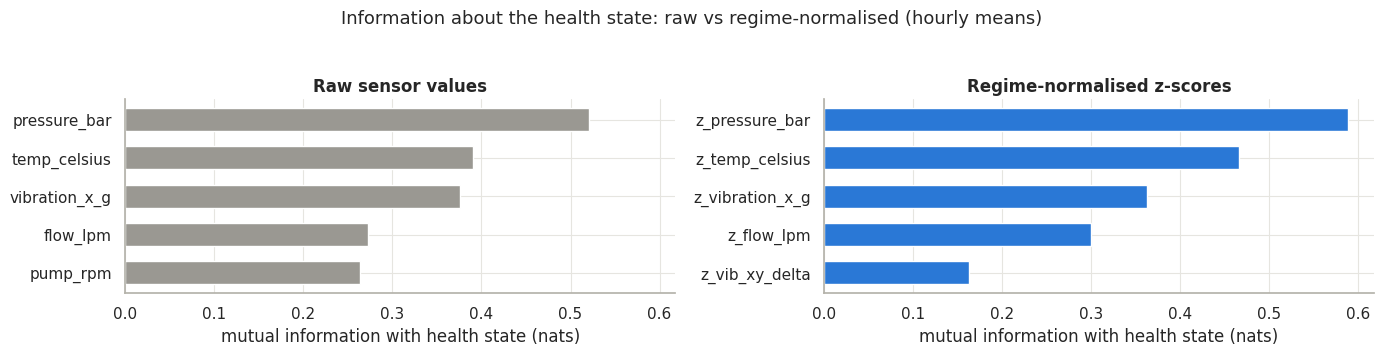

Total MI — raw (excl. rpm): 1.56 nats | regime-normalised: 1.88 nats


median healthy rpm,Day,Night,Weekend
machine_id,,,
HPU_01,"1,515.000","1,471.000","1,450.000"
HPU_02,"1,526.000","1,482.000","1,461.000"
HPU_03,"1,519.000","1,474.000","1,452.000"
HPU_04,"1,529.000","1,484.310","1,462.500"
HPU_05,"1,513.000","1,469.000","1,447.000"
HPU_06,"1,525.000","1,481.000","1,459.000"
HPU_07,"1,517.000","1,473.000","1,450.000"
HPU_08,"1,530.000","1,485.000","1,463.000"
HPU_09,"1,519.000","1,475.000","1,454.000"


In [41]:
# Raw sensors vs regime-normalised features: how much information does each carry about the health state?
def mi_scores(cols):
    X = hourly[cols].fillna(hourly[cols].median())
    return pd.Series(mutual_info_classif(X, hourly.state, random_state=RANDOM_STATE), index=cols)
mi_raw = mi_scores(["pressure_bar", "temp_celsius", "flow_lpm", "vibration_x_g", "pump_rpm"])
mi_z = mi_scores(ZFEATS)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.4), sharex=True)
for ax, m, t, c in [(axes[0], mi_raw, "Raw sensor values", MODE_COLORS["healthy"]),
                    (axes[1], mi_z, "Regime-normalised z-scores", MODE_COLORS["pump_wear"])]:
    m = m.sort_values(); ax.barh(m.index, m.values, color=c, height=0.6); ax.set(title=t, xlabel="mutual information with health state (nats)")
fig.suptitle("Information about the health state: raw vs regime-normalised (hourly means)", y=1.04, fontsize=13)
plt.tight_layout(); save(fig, "09_mutual_information"); plt.show()
print(f"Total MI — raw (excl. rpm): {mi_raw.drop('pump_rpm').sum():.2f} nats | regime-normalised: {mi_z.sum():.2f} nats")
# Why does rpm carry information? Each machine has its own set point, so rpm identifies the machine
display(df[(df.state == "healthy") & ~df.is_standby].groupby(["machine_id", "regime"], observed=True)["pump_rpm"]
          .median().unstack()[SHIFT_ORDER].rename_axis(columns="median healthy rpm"))

**Findings: statistics**

- **Large effect sizes** confirm the fingerprints:
  - pressure (δ ≈ −0.7) and vibration (δ ≈ +1.0) for pump wear
  - temperature (δ ≈ +0.9) and flow (δ ≈ −0.7) for valve leakage
  - vibration (δ = 1.0) for contamination
  - the X−Y delta (δ = 1.0) for cylinder drift
- **Contamination looks weaker on pressure and temperature** because its signal is concentrated in the final ~48 h. That argues for **short-window, peak-based vibration features** (max, 99th percentile, kurtosis, spectral energy).
- **Pump rpm does not change with degradation**: Kruskal–Wallis H is 20–90× smaller than for the other sensors, and every |δ| is below 0.15.
- **Yet raw rpm still scores a noticeable mutual information.** The reason is a **machine-identity leak**: each HPU runs at its own slightly different rpm set point (±8 rpm, see the check below), and each machine has only one failure mode. A model can learn "1,485 rpm ⇒ HPU_04 ⇒ pump wear" and look accurate in a random split while learning nothing about wear. This is the strongest argument for **leave-one-machine-out validation**, and for using rpm only as regime context.
- **Regime-normalised features carry more information** about the health state than the raw values (total MI 1.88 vs 1.56 nats) and do not encode machine identity, which supports the normalisation approach for Stage 2.

## 10. Failure events, maintenance history and business impact

### 10.1 Cost and downtime of failures

,events,total_repair_usd,mean_repair_usd,total_downtime_h,mean_downtime_h
failure_mode,,,,,
pump_wear,3,84912,"28,304.000",50.100,16.700
valve_leakage,3,34374,"11,458.000",26.700,8.900
contamination,2,40989,"20,494.500",16.800,8.400
cylinder_drift,1,23021,"23,021.000",13.100,13.100


TOTAL across 9 failures: repair $183,296, downtime 106.7 h


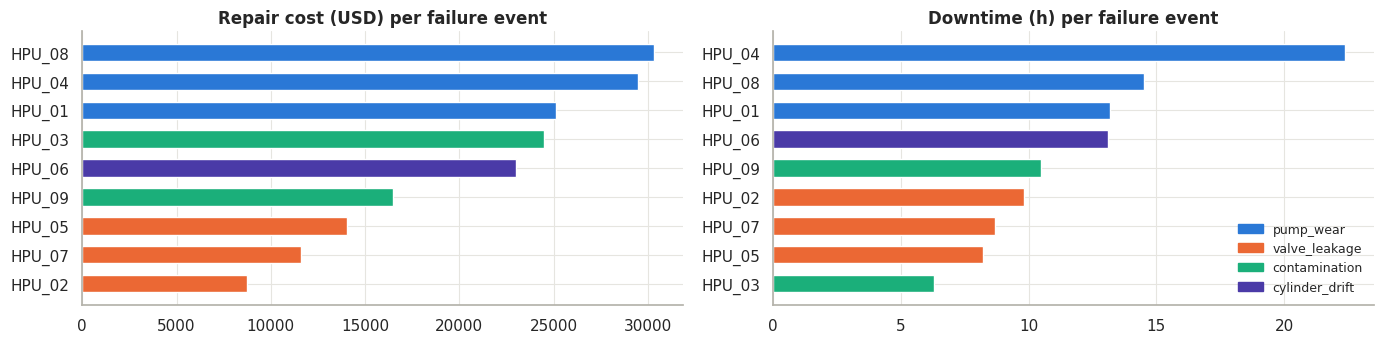

In [42]:
fe = fail.assign(cost_per_downtime_h=fail.repair_cost_usd / fail.downtime_hours)
summary = fe.groupby("failure_mode").agg(events=("machine_id", "size"), total_repair_usd=("repair_cost_usd", "sum"),
                                         mean_repair_usd=("repair_cost_usd", "mean"), total_downtime_h=("downtime_hours", "sum"),
                                         mean_downtime_h=("downtime_hours", "mean")).reindex(MODES)
display(summary)
print(f"TOTAL across 9 failures: repair ${fail.repair_cost_usd.sum():,.0f}, downtime {fail.downtime_hours.sum():.1f} h")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for ax, col, lab in [(axes[0], "repair_cost_usd", "Repair cost (USD)"), (axes[1], "downtime_hours", "Downtime (h)")]:
    f = fail.sort_values(col)
    ax.barh(f.machine_id, f[col], color=[MODE_COLORS[m] for m in f.failure_mode], height=0.6)
    ax.set(title=lab + " per failure event")
handles = [plt.Rectangle((0, 0), 1, 1, color=MODE_COLORS[m]) for m in MODES]
axes[1].legend(handles, MODES, loc="lower right", fontsize=9)
plt.tight_layout(); save(fig, "10_failure_costs"); plt.show()

**Findings: failure impact**

- **Pump wear is the most expensive mode** (≈ $28k and 16.7 h downtime per event; HPU_04 alone lost 22.4 h). Across the 9 failures, repairs cost **$183k** and caused **107 h** of downtime. It is also the mode with the **longest and clearest warning signal** (§8.3), so it is the obvious first target for ROI.
- Valve leakage is as frequent as pump wear (3 of 9 events each) but costs less than half as much per event. Contamination and cylinder drift are rarer but still cost more than $20k per event.
- Note: `repair_cost_usd` excludes lost production. With a production-loss rate per hour (to be supplied by the business), downtime can be converted into a full cost of failure for the ROI case.

### 10.2 Maintenance log profile

,actions,mean_cost,median_cost,total_cost
action_type,,,,
Inspection,4,641.500,626.000,2566
Preventive,33,"1,211.364","1,166.000",39975
Reactive,14,"3,961.500","3,524.500",55461


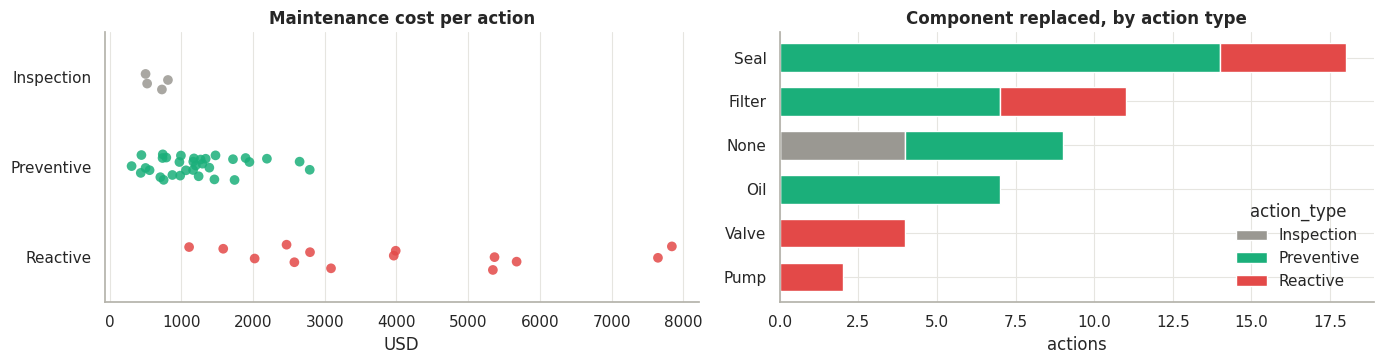

Reactive actions cost 3.3× more than preventive actions on average


In [43]:
display(mnt.groupby("action_type").agg(actions=("maintenance_id", "size"), mean_cost=("cost_usd", "mean"),
                                       median_cost=("cost_usd", "median"), total_cost=("cost_usd", "sum")).sort_values("mean_cost"))
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
order_at = mnt.groupby("action_type").cost_usd.median().sort_values().index
ACTION_COLORS = {"Preventive": MODE_COLORS["contamination"], "Reactive": MODE_COLORS["post_failure"], "Inspection": MODE_COLORS["healthy"]}
sns.stripplot(data=mnt, x="cost_usd", y="action_type", order=order_at, hue="action_type", palette=ACTION_COLORS, legend=False,
              ax=axes[0], size=7, alpha=0.85, jitter=0.15)
axes[0].set(title="Maintenance cost per action", xlabel="USD", ylabel="")
ct = pd.crosstab(mnt.component_replaced, mnt.action_type)
ct.loc[ct.sum(axis=1).sort_values().index].plot.barh(stacked=True, ax=axes[1], width=0.65,
       color=[ACTION_COLORS[c] for c in ct.columns], edgecolor="white")
axes[1].set(title="Component replaced, by action type", xlabel="actions", ylabel="")
plt.tight_layout(); save(fig, "10_maintenance"); plt.show()
ratio = mnt.loc[mnt.action_type == "Reactive", "cost_usd"].mean() / mnt.loc[mnt.action_type == "Preventive", "cost_usd"].mean()
print(f"Reactive actions cost {ratio:.1f}× more than preventive actions on average")

**Findings: maintenance**

- **Reactive work costs about 3× more than preventive work** on average, and all pump and valve replacements were reactive. This is the core quantitative argument for predictive maintenance.
- No `Predictive` actions exist, which confirms the "reactive culture" described in the brief. This project would introduce that category.

### 10.3 Timeline alignment across the three sources

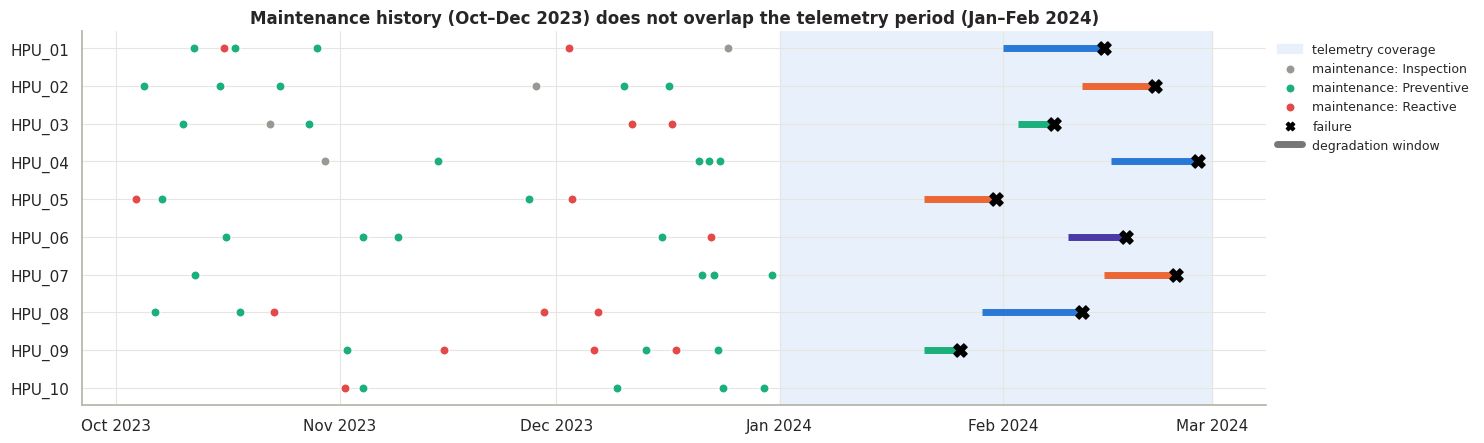

Maintenance date range: 2023-10-03 → 2023-12-30
Telemetry date range  : 2024-01-01 → 2024-02-29


In [44]:
fig, ax = plt.subplots(figsize=(15, 4.6))
machines = sorted(tel.machine_id.unique())
ymap = {m: i for i, m in enumerate(machines)}
ax.axvspan(tel.timestamp.min(), tel.timestamp.max(), color="#e8f0fb", zorder=0, label="telemetry coverage")
at_colors = ACTION_COLORS
for at, g in mnt.groupby("action_type"):
    ax.scatter(g.action_timestamp, g.machine_id.map(ymap), marker="o", s=45, color=at_colors[at], label=f"maintenance: {at}", zorder=3, edgecolor="white")
for _, e in fail.iterrows():
    y = ymap[e.machine_id]
    ax.plot([e.degradation_start_timestamp, e.failure_timestamp], [y, y], color=MODE_COLORS[e.failure_mode], lw=5, solid_capstyle="butt")
    ax.scatter(e.failure_timestamp, y, marker="X", s=90, color="black", zorder=4)
ax.scatter([], [], marker="X", color="black", label="failure"); ax.plot([], [], lw=5, color="#777", label="degradation window")
ax.set_yticks(range(len(machines))); ax.set_yticklabels(machines); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title="Maintenance history (Oct–Dec 2023) does not overlap the telemetry period (Jan–Feb 2024)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.tight_layout(); save(fig, "10_timeline"); plt.show()

print("Maintenance date range:", mnt.action_timestamp.min().date(), "→", mnt.action_timestamp.max().date())
print("Telemetry date range  :", tel.timestamp.min().date(), "→", tel.timestamp.max().date())

In [45]:
# What happened on each machine in the maintenance history before its failure?
last = (mnt.sort_values("action_timestamp").groupby("machine_id")
          .agg(last_action=("action_timestamp", "last"), last_type=("action_type", "last"),
               n_reactive=("action_type", lambda s: (s == "Reactive").sum()), components=("component_replaced", lambda s: ", ".join(sorted(set(s) - {"None"})))))
hist = fail.set_index("machine_id")[["failure_mode"]].join(last, how="right")
hist["days_since_last_action_at_failure"] = (fail.set_index("machine_id").failure_timestamp - hist.last_action).dt.days
hist

,failure_mode,last_action,last_type,n_reactive,components,days_since_last_action_at_failure
machine_id,,,,,,
HPU_01,pump_wear,2023-12-24 20:16:00,Inspection,2,"Filter, Seal",52.000
HPU_02,valve_leakage,2023-12-16 13:59:00,Preventive,0,"Filter, Oil, Seal",67.000
HPU_03,contamination,2023-12-17 02:40:00,Reactive,2,"Pump, Seal",52.000
HPU_04,pump_wear,2023-12-23 15:47:00,Preventive,0,"Oil, Seal",66.000
HPU_05,valve_leakage,2023-12-03 05:36:00,Reactive,2,"Filter, Oil, Seal, Valve",58.000
HPU_06,cylinder_drift,2023-12-22 12:28:00,Reactive,1,"Oil, Pump, Seal",57.000
HPU_07,valve_leakage,2023-12-30 21:35:00,Preventive,0,Filter,56.000
HPU_08,pump_wear,2023-12-06 20:47:00,Reactive,3,"Filter, Seal, Valve",67.000
HPU_09,contamination,2023-12-23 10:16:00,Preventive,3,"Filter, Seal, Valve",33.000


**Findings: maintenance vs telemetry**

- **The maintenance log (3 Oct – 30 Dec 2023) ends before telemetry begins (1 Jan 2024), and there are no records of the repairs that obviously happened after the 9 failures.** Maintenance events therefore cannot be linked to sensor behaviour (DQ-08). The 2024 CMMS records are needed.
- What can still be used: static machine-level history such as **number of prior reactive interventions** and **days since last maintenance at the start of the window** (the "Static vs Dynamic data" point in the brief).
- HPU_10, the only machine that never failed, does not stand out in the maintenance history: it had 1 reactive action and was last serviced on 29 Dec, like its peers. **The 2023 maintenance log alone does not explain which machines failed.** At n = 10 we would not expect it to.

## 11. Summary of findings and recommendations for Stage 2

### 11.1 Key insights

| # | Insight | Evidence | Consequence |
|---|---------|----------|-------------|
| 1 | **Every failure mode has a distinct, physically plausible sensor fingerprint** | §8.1–8.2, §9.2 | Failure-mode classification is feasible |
| 2 | **Simple rules already give warnings days in advance**: ~10–12 d for pump wear, ~8 d for valve leakage, ~5 d for cylinder drift, but only 2–3 d for contamination | §8.3 | Baseline for ML to beat; realistic per-mode alerting targets |
| 3 | **Operating regime is the largest source of variance** in healthy data (Day / Night / Weekend set points, a midnight dip, and an undocumented fleet-wide standby day) | §4.4, §7 | Features must be normalised per machine × day type × hour; with that, the rules raised no false alarms in ~12,000 healthy hours |
| 4 | **The supplied RUL target is flawed** (500 h sentinel, discontinuity, zeros after repair) | §6.3 | Target must be rebuilt from `failure_labels.csv` |
| 5 | `is_anomaly` **is the label**, not a feature | §6.1 | Exclude from inputs to avoid leakage |
| 6 | **Only 9 failure episodes** (1 for cylinder drift), one failure mode per machine, and machine-specific rpm set points that act as an identity leak | §6.2, §9.2 | Leave-one-machine-out validation; honest uncertainty reporting |
| 7 | **Vibration Y duplicates X ~98% of the time**; the X−Y divergence is diagnostic | §4.6, §8.4 | Escalate to data owner; engineer the delta feature |
| 8 | **Single-minute sensor glitches** (pressure > 350 bar, negative oil temperature) and short dropouts | §4.1–4.3 | Invalidate-and-interpolate rules in the validation layer; do not over-filter the real vibration bursts |
| 9 | **Reactive maintenance costs ~3× preventive**; pump wear is the costliest failure | §10 | Business case; prioritise pump wear for the first release |
| 10 | **Maintenance log does not overlap telemetry** | §10.3 | Request 2024 CMMS data |

### 11.2 Proposed Stage 2 plan (data validation and feature engineering), for your confirmation

1. **Validation layer** (`src/data/validate.py`, `pandera` schema): enforce the data contract, the range rules (DQ-02/03), regime tagging including standby days (DQ-04), gap interpolation of 15 min or less with an imputed flag (DQ-01), and quarantine of non-conforming batches. Unit-tested so it can run in GitHub Actions later.
2. **Target rebuild:** piecewise-linear RUL (`min(hours_to_failure, cap)`), post-failure rows excluded, HPU_10 treated as censored; failure-mode label taken from `failure_labels.csv`.
3. **Feature families:**
   - Regime-normalised residuals (per machine × day type × hour-of-day baseline, as in §8.1)
   - Rolling statistics over 1 h / 6 h / 24 h windows (mean, std, min, max, quantiles, slope/trend)
   - Lag and difference features
   - Vibration: peak, kurtosis, crest factor, rolling FFT band energy
   - Cross-sensor: X−Y vibration delta, pressure/flow ratio (efficiency proxy), rolling correlations
   - Context: shift, hour, days since last maintenance
4. **Aggregation grain:** move from 1-min rows to **hourly (or 15-min) windows**, which reduces autocorrelation and dataset size by about 60×.
5. **Validation strategy:** **leave-one-machine-out** cross-validation, plus a time-ordered hold-out. Metrics: macro-F1 for mode classification (imbalance), MAE/RMSE on capped RUL, and **lead time at a fixed false-alarm rate** as the business metric. The §8.3 rule-based baseline is the bar to beat.

### 11.3 Open questions for the data owner

1. Is `vibration_y_g` a real separate accelerometer? (DQ-05)
2. What happened on 15 Jan, when every HPU ran at 1,000 rpm and about 50 bar all day? Do standby days recur, and are they recorded in MES? (DQ-04)
3. Can we get exact failure timestamps and 2024 maintenance and repair records? (DQ-06, DQ-08)
4. Are timestamps UTC? What is the production-loss cost per downtime hour?
5. Engineering sign-off on the physical range bounds in §4.3.

In [46]:
# Persist the EDA outputs used by later stages (on Colab + Drive, copy them next to the data so they survive the session)
import shutil
if IN_COLAB and USE_DRIVE:
    dest = DATA_DIR.parent.parent / "reports"
    shutil.copytree(REPORT_DIR, dest, dirs_exist_ok=True)
    print("Copied reports to", dest)
print("Saved artefacts:")
for p in sorted(REPORT_DIR.rglob("*")):
    if p.is_file(): print("  ", p)

Saved artefacts:
   reports/baseline_lead_times.csv
   reports/data_quality_register.csv
   reports/figures/04_dropouts.png
   reports/figures/04_pressure_spikes.png
   reports/figures/04_standby_day.png
   reports/figures/05_distributions.png
   reports/figures/06_class_balance.png
   reports/figures/06_rul_construction.png
   reports/figures/07_acf.png
   reports/figures/07_fleet_heatmap.png
   reports/figures/07_hour_profile.png
   reports/figures/07_regimes.png
   reports/figures/08_fingerprint.png
   reports/figures/08_lead_time.png
   reports/figures/08_trajectories.png
   reports/figures/08_xy_divergence.png
   reports/figures/09_correlations.png
   reports/figures/09_mutual_information.png
   reports/figures/10_failure_costs.png
   reports/figures/10_maintenance.png
   reports/figures/10_timeline.png
